<a href="https://colab.research.google.com/github/liron7722/AI-Generated-Text-Detector/blob/Production/AI_Generated_Text_Detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

אסתר: הוספתי עוד עמודה של מספר המשפטים בטקסט, אחרי שראיתי שיש ערכים חריגים באורכי מילים בטקסטים מגונרטים.

לדעתי כדאי לשמור DF חדש

לדיון- האם לעשות משהו עם הערכים החריגים של אורכי מילים, ואם כן - מה.

NGRAMS אורן אמר בפגישה האחרונה שכדאי לעשות צירופים של 10 מילים



todo clusteriung and then the distance from the cluster
PCA
increace to 2-6 ngrams 1k-10k
to look on the words from ngrams and see they are informative

histogram on POS (not needed)

see what feature helped more and what helped less

next phase is text embaddings

NLPCC 2026 Shared Task 6: The Second Shared Task on LLM-Generated Text Detection

# TO-DO




Done:
* GH Proejct created
* Getting larger Dataset
* EDA Start
* Do comperistion between Generated and not Generated Words\Sentences count
* Use n-grams - Combination of group of words
* Complete EDA Visualization (Ester)

Do not do
- do lower case manipulation on the text


Next Steps
* Balance the data by multiple smaller class by 3 (Ester)
* Complete Feaures (Liron)
* Create Models (Ester)


Optional (Future)
- make graph of our etl or models


## Deck Remarks

Inital Deck remarks

* מספרי כרטסיטיות
* גופן
* יותר מידי זמן על הרקע
* יותר הסברים על הפיצרים
* לא להתרכז ב f1
* להגדיל כתב ולנצל שטח פתוח
* להסביר על הטיפול באיזון של המידע
* שיהיה קוד שנהיה גאים בו ונפגין יכולות
* עמוד פתיחה עם תמונה רלוונטית
* בהצגה סופית להסביר טכני
* להראות דוגמא של טקסט ממכונה והלראות שזה לא פשוט לנחש
* שיהיה בשר תכנותי, לשקול לכתוב מודל משלנו
* דברים שעושים במצגות ברמה גבוהה
* מוסיפים איזה אייקון לכל שקופית מספר פעמים ומבקשים מהקהל להגיד כמה היה בסוף המצגת
* לפני ששואלים שאלה אותנו אז נבקש להגיד מילת מפתח כמו השם של הקבוצה שלנו או משהו מהותי למצגת שלנו
בסוף כל המצגות נראה שאמרו את המיל מפתח שלנו הכי הרבה
בגרף של המילים
* לשאול את הכיתה בהתחלה כמה מהמצגת שלנו נוצרה ע"י LLM








###### KaggleCompetition

In [ ]:
# KaggleCompetition = 'https://www.kaggle.com/competitions/llm-detect-ai-generated-text/overview'



```
File and Field Information

{test|train}_essays.csv
id - A unique identifier for each essay.
prompt_id - Identifies the p\rompt the essay was written in response to.
text - The essay text itself.
generated - Whether the essay was written by a student (0) or generated by an LLM (1).
This field is the target and is not present in test_essays.csv.

train_prompts.csv - Essays were written in response to information in these fields.
prompt_id - A unique identifier for each prompt.
prompt_name - The title of the prompt.
instructions - The instructions given to students.
source_text - The text of the article(s) the essays were written in response to, in Markdown format.
Significant paragraphs are enumerated by a numeral preceding the paragraph on the same line, as in 0 Paragraph one.
Paragraph two.. Essays sometimes refer to a paragraph by its numeral.
Each article is preceded with its title in a heading, like # Title.
When an author is indicated, their name will be given in the title after by.
Not all articles have authors indicated. An article may have subheadings indicated like ## Subheading.

sample_submission.csv - A submission file in the correct format. See the Evaluation page for details.
```



# CFG
class for variables

In [1]:
class CFG:
  verbose = 0  # Verbosity
  isLocal = False  
  run_notebook_from_scracth = False
  
  wandb = True  # Weights & Biases logging
  wandb_secret_key = 'WANDB_API_KEY'
  competition = 'llm-detect-ai-generated-text'  # Competition name
  _wandb_kernel = 'awsaf49'  # WandB kernel
  comment = 'DebertaV3-MaxSeq_200-ext_s-torch'  # Comment description

  preset = "deberta_v3_base_en"  # Name of pretrained models
  sequence_length = 200  # Input sequence length


  seed = 42  # Random seed

  num_folds = 5  # Total folds
  selected_folds = [0, 1]  # Folds to train on


config = CFG()

# Importing Libraries

In [2]:
# General
import numpy as np
import pandas as pd
import io
import sys
import math
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import string
import re
import nltk
import logging
import wandb
import os
import joblib
import pyarrow as pa

try:
    from google.colab import userdata
    print("Running on Google Colab")
except ImportError:
    print("Running locally")
    config.isLocal = True


from tqdm import trange
from nltk import tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.probability import FreqDist
from nltk.util import ngrams
#from nltk.util import ngram_freq
from nltk.translate import nist_score
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

# Pre Models Training
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import RFE

# Models
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier


cmap = mpl.colormaps.get_cmap('coolwarm')


import warnings
warnings.filterwarnings('ignore')
for pkg in ['omw-1.4', 'punkt', 'punkt_tab', 'averaged_perceptron_tagger', 'stopwords', 'averaged_perceptron_tagger_eng']:
  nltk.download(pkg, quiet=True)

if config.wandb:
  wandb.login(key= os.environ.get(config.wandb_secret_key) if config.isLocal else userdata.get(config.wandb_secret_key))

Running locally


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/wangkongqiang/.netrc.
wandb: Currently logged in as: wangkongqiang60 (wangkongqiang60-yunnan-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


# Loading Data

## raw data

In [3]:
if config.run_notebook_from_scracth:
    train_essays = pd.read_csv('https://raw.githubusercontent.com/liron7722/AI-Generated-Text-Detector/refs/heads/Production/data/train_essays.csv')
    train_prompts = pd.read_csv('https://raw.githubusercontent.com/liron7722/AI-Generated-Text-Detector/refs/heads/Production/data/train_prompts.csv')
    train_essays.head()

In [4]:
if config.run_notebook_from_scracth:
    text_df = pd.read_parquet('https://github.com/liron7722/AI-Generated-Text-Detector/raw/refs/heads/Production/data/train_essays.parquet')
# data after basic EDA
# text_df=pd.read_csv('https://media.githubusercontent.com/media/liron7722/AI-Generated-Text-Detector/refs/heads/Production/data/text_df_2024_11_14.csv')
# text_df=pd.read_csv('./data/train_essays.csv')
text_df=pd.read_csv('./NLPCC-2026-Task6-Detection/data/train_data.csv')
text_df

,id,prompt_id,text,generated
0,GPT4-News-Rewrite-ID-2003_HWT,0,偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...,0
1,GPT4-News-Rewrite-ID-2003_HLT,1,广州市一名男子因涉嫌盗窃并无证驾驶一辆紫色BRT公交车而被警方逮捕。据警方报告，8月18日下...,1
2,GPT4-News-Rewrite-ID-2003_LGT,2,偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...,2
3,GPT4-News-Rewrite-ID-2001_HWT,0,编者按：教育培训的市场方面，做地推是一个重要的渠道，作者结合自己的实战经验，为教育培训行业的...,0
4,GPT4-News-Rewrite-ID-2001_HLT,1,在教育培训领域，有效的市场推广策略是吸引学生和家长的关键。一位资深市场专家分享了他的实战经验...,1
...,...,...,...,...
58897,Baichuan-Thesis-Polish-ID-1998_HLT,1,中国封建社会的世界是男人的世界，中国古代的文学也是男性的文学，女性的才情就如那“三寸金莲”般...,1
58898,Baichuan-Thesis-Polish-ID-1998_LGT,2,中国封建社会的世界是男人的世界，中国古代的文学也是男性的文学，女性的才情就如那“三寸金莲”般...,2
58899,Baichuan-Thesis-Polish-ID-1999_HWT,0,由于考古学家、历史学家、古文字学家，以及有关研究工作者的努力开垦，我们现在已经可以看到许多先...,0
58900,Baichuan-Thesis-Polish-ID-1999_HLT,1,由于考古学家、历史学家、古文字学家，以及有关研究工作者的努力开垦，我们现在已经可以看到许多先...,1


In [5]:
text_df_1=pd.read_csv('./NLPCC-2026-Task6-Detection/data/testp1_data.csv')
text_df_1

,id,prompt_id,text,generated
0,testp1-0,-1,义乌景升工艺品有限公司：高品质油画定制专家，为您的空间增添艺术魅力在追求生活品质的今天，油画...,-1
1,testp1-1,-1,《法医学杂志》，2020年2月，第36卷，第1期 1 案例 1.1 简要案情 患者常某，男性...,-1
2,testp1-2,-1,上述研究显示，单部位或双部位的颅内硬脑膜下积液量较少，损伤主要由蛛网膜破裂引起，症状较轻；而...,-1
3,testp1-3,-1,户外速干防晒衣：高性价比尾货，无惧瑕疵，乐享UPF50专业防护！还在为高昂的品牌溢价买单吗？...,-1
4,testp1-4,-1,特别声明: 具体见颜色选项(本店自定义颜色可能与出厂标签表述不同属正常现象) 1. 默认中通...,-1
...,...,...,...,...
3595,testp1-3595,-1,分析化学实验：科学的基石与未来的桥梁分析化学实验，作为化学学科的重要组成部分，是连接理论知识...,-1
3596,testp1-3596,-1,苯醚甲环唑在茉莉花及其制品中的消解与转移行为研究摘要本研究旨在探讨茉莉花及其制品中农药残留的...,-1
3597,testp1-3597,-1,力度空前，财政政策更加积极有为——代表委员和专家解读预算报告 2020年05月27日 08:...,-1
3598,testp1-3598,-1,"深圳楼市调控加码的""靴子""终于落地 阻击楼市投机客 时间 : 2020-07-16 13:5...",-1


In [6]:
text_df_2=pd.read_csv('./NLPCC-2026-Task6-Detection/data/testp2_data.csv')
text_df_2

,id,prompt_id,text,generated
0,testp2-0,-1,邦士度眼镜成功通过ISO9001-2015质量管理体系认证 标志质量管理迈上新台阶近日，广州...,-1
1,testp2-1,-1,法赫里·科鲁蒂尔克 法赫里·萨比特·科鲁蒂尔克（土耳其語：Fahri Sabit Korut...,-1
2,testp2-2,-1,在现代居家办公和学习的需求下，一款设计精美且功能实用的笔记本电脑桌显得尤为重要。宜宝诗品牌推...,-1
3,testp2-3,-1,彼得·科斯格罗夫 彼得·約翰·科斯格罗夫爵士，AK，CVO，MC（英語：Sir Peter ...,-1
4,testp2-4,-1,五人斗地主：双倍刺激的扑克新玩法在传统斗地主风靡全国多年后，一种更具挑战性的变体——五人斗地...,-1
...,...,...,...,...
1147,testp2-1147,-1,CHAFFUL气垫BB霜：一拍即美，定义无瑕轻裸肌！想要告别繁琐的底妆步骤，轻松打造自然无瑕...,-1
1148,testp2-1148,-1,集美们，这个是福利！看到了就必须冲的系列这个之前在日本真的很火很贵！！！可以看猫店现在都是1...,-1
1149,testp2-1149,-1,关于英国直邮掌柜：可乐妈身处英国，亲自选购商品，并采用气柱包装。。 免费提供视频、发票、记号...,-1
1150,testp2-1150,-1,10月6日晚，中国福利彩票双色球游戏进行第2020097期开奖，开出的红球号码为02、08、...,-1


## after basic EDA

## NGrams_data

In [7]:
# NGrams_data = pd.read_csv('https://media.githubusercontent.com/media/liron7722/AI-Generated-Text-Detector/refs/heads/Production/data/tfidf_ngram_features.csv')
# NGrams_data = pd.read_csv('tfidf.csv')
NGrams_data = pd.read_csv('tdidf-nlpcc.csv')

# EDA

In [8]:
# text_df['text'][165763]
text_df['text'][165]

'多知网4月17日消息，在第十六届中国国际人才交流大会上，好未来旗下CareerChina发布外教“千人计划”，将为国内教育机构从海外引进符合工签标准的千余名母语外籍教师。同时，配合千人计划的“PROME”外籍人才智能云平台正式上线。据了解，CareerChina是好未来旗下专门为国内教育机构提供外教来华招聘、签证、管理、生活等一站式服务的外籍人力资源服务平台。2017年2月成立至今，CareerChina已形成海外高品质外籍人才规模引流、线上招聘、签证专业支持和客户管理的全线布局，并为行业成功输送三百多名母语工签外教。CareerChina负责人张文静表示，CareerChina在2016年与国家外国专家局下属机构中国国际人才市场签署了战略合作协议，双方将共同引进海外高品质外籍人才，为国内教育机构建立海外雇主品牌、提供政策咨询服务搭建平台，并宣布“PROME”外籍人才智能云平台正式上线。“PROME”系统是CareerChina产品研发团队为外事招聘行业打造的外教人才招聘管理平台。通过“PROME”发布的职位，能同步到国外各大主流招聘平台，通过海外搜索引擎优化和社交媒体运营矩阵吸引外国人才投递简历。同时，针对外事招聘行业的痛点，“PROME”还推出面试预约，在线视频面试、视频自动录制、邮件及短信提醒等沟通功能，系统还可以高效精准的将筛选后的应聘者信息通过线上推送的方式直接发送到用人单位。从国家外专局数据中显示，目前在中国大陆工作的外国人已超过90万人次，其中有近40万人次从事教育行业工作，而符合最新国家政策要求的工签外教数量只占外国人教育行业从业数量的三分之一。随着国际化程度的提升，中国未来教育行业对外籍人才的需求将在百万人以上，在消费升级浪潮下个性化学习的意识与日俱增，线下及线上全球优质专业外教资源将格外紧俏。在谈到外教招聘行业未来发展时，中国国际人才市场国际教育部部长王雨石表示，教育机构由于自身招聘能力有限，通过招聘服务机构招聘外教是最常见的合作方式，判断一家外教招聘机构是否能提供专业支持和服务保障，一要看机构工作人员是否具备符合政策要求的专业咨询、指导和建议的能力；二要看公司的主体性质，是否专业从事人力资源服务；三要看是否能持续稳定的提供母语外教资源。希望CareerChina能做出外教服务领域的高标准，在行业中更加专业化、规范化。作为一家从事外教服务的人力

In [9]:
text_df['generated'].value_counts()

generated
0    19634
1    19634
2    19634
Name: count, dtype: int64

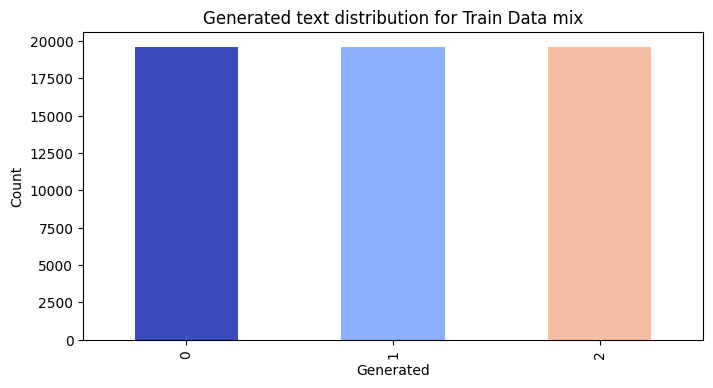

In [10]:
# Show distribution of generated text using a bar plot
plt.figure(figsize=(8, 4))
text_df.generated.value_counts().plot.bar(color=[cmap(0.0), cmap(0.25), cmap(0.65), cmap(0.9), cmap(1.0)])
plt.xlabel("Generated")
plt.ylabel("Count")
plt.title("Generated text distribution for Train Data mix")
plt.show()

In [11]:
counts = text_df[['prompt_id','generated']].value_counts().sort_index()
# counts = text_df[['generated']].value_counts().sort_index()

In [12]:
counts

prompt_id  generated
0          0            19634
1          1            19634
2          2            19634
Name: count, dtype: int64

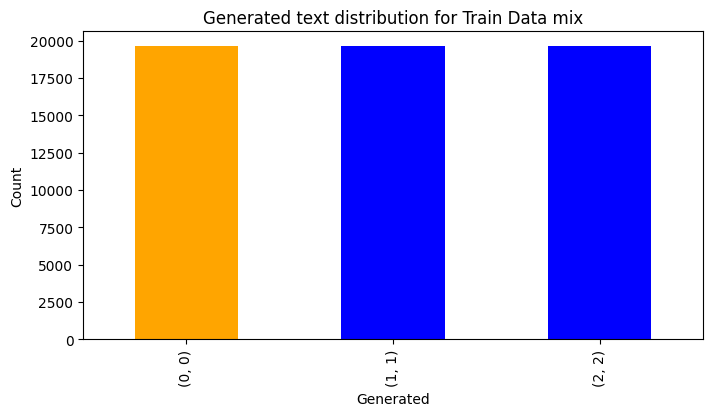

In [13]:
# Show distribution of generated text using a bar plot
plt.figure(figsize=(8, 4))
# text_df[['prompt_id','generated']].value_counts().sort_index().plot.bar()
counts.plot(kind='bar', color=['orange' if i[1] == 0 else 'blue' for i in counts.index])
plt.xlabel("Generated")
plt.ylabel("Count")
plt.title("Generated text distribution for Train Data mix")
plt.show()

## Removing Duplicate Rows

In [14]:
# Removing Duplicate Rows
text_df = text_df.drop_duplicates(subset=['text'])
text_df.reset_index(drop=True, inplace=True)

In [15]:
# chech for missing data
text_df.isnull().sum()
# text_df.count()

id           0
prompt_id    0
text         1
generated    0
dtype: int64

In [16]:
text_df_1.isnull().sum()

id           0
prompt_id    0
text         0
generated    0
dtype: int64

In [17]:
text_df_2.isnull().sum()

id           0
prompt_id    0
text         0
generated    0
dtype: int64

In [18]:
text_df["text"] = text_df["text"].fillna("").astype(str)

## Counts and Lenght:
### Start by checking how long the reviews are


*   Character count
*   Word count
*   Mean word length
*   Mean sentence length
*   Sentence count

In [19]:
lenght = len(text_df['text'][0])
print(f'Character Count of a sample assay: {lenght}')

Character Count of a sample assay: 1425


In [20]:
text_df['Character_Count'] = text_df['text'].str.len()
text_df.head(10)

,id,prompt_id,text,generated,Character_Count
0,GPT4-News-Rewrite-ID-2003_HWT,0,偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...,0,1425
1,GPT4-News-Rewrite-ID-2003_HLT,1,广州市一名男子因涉嫌盗窃并无证驾驶一辆紫色BRT公交车而被警方逮捕。据警方报告，8月18日下...,1,187
2,GPT4-News-Rewrite-ID-2003_LGT,2,偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...,2,1063
3,GPT4-News-Rewrite-ID-2001_HWT,0,编者按：教育培训的市场方面，做地推是一个重要的渠道，作者结合自己的实战经验，为教育培训行业的...,0,1677
4,GPT4-News-Rewrite-ID-2001_HLT,1,在教育培训领域，有效的市场推广策略是吸引学生和家长的关键。一位资深市场专家分享了他的实战经验...,1,498
5,GPT4-News-Rewrite-ID-2001_LGT,2,编者按：教育培训的市场方面，做地推是一个重要的渠道，作者结合自己的实战经验，为教育培训行业的...,2,1222
6,GPT4-News-Rewrite-ID-2000_HWT,0,"中国新闻网2014-09-1717:18:44中新网9月17日电记者今日获悉,包括中信国际、...",0,1174
7,GPT4-News-Rewrite-ID-2000_HLT,1,宁波市的16家顶级酒店近日宣布，将不再通过携程网站接受预订，转而独家在去哪儿网上提供房间。这...,1,771
8,GPT4-News-Rewrite-ID-2000_LGT,2,"中国新闻网2014-09-1717:18:44中新网9月17日电记者今日获悉,包括中信国际、...",2,1266
9,GPT4-News-Rewrite-ID-2005_HWT,0,多知网2月10日消息，近日北京市教委发布了2015年北京市义务教育入学政策。今年特长生招生项...,0,1130


In [21]:
text_df_1['Character_Count'] = text_df_1['text'].str.len()
text_df_1.head(10)

,id,prompt_id,text,generated,Character_Count
0,testp1-0,-1,义乌景升工艺品有限公司：高品质油画定制专家，为您的空间增添艺术魅力在追求生活品质的今天，油画...,-1,949
1,testp1-1,-1,《法医学杂志》，2020年2月，第36卷，第1期 1 案例 1.1 简要案情 患者常某，男性...,-1,1277
2,testp1-2,-1,上述研究显示，单部位或双部位的颅内硬脑膜下积液量较少，损伤主要由蛛网膜破裂引起，症状较轻；而...,-1,888
3,testp1-3,-1,户外速干防晒衣：高性价比尾货，无惧瑕疵，乐享UPF50专业防护！还在为高昂的品牌溢价买单吗？...,-1,960
4,testp1-4,-1,特别声明: 具体见颜色选项(本店自定义颜色可能与出厂标签表述不同属正常现象) 1. 默认中通...,-1,1312
5,testp1-5,-1,本店已开通实拍保护， 严禁盗图， 系统自动处罚无法申诉！ @新老顾客们，靠实力说话， 信我的...,-1,734
6,testp1-6,-1,您现在的位置是：主页 > 电商 > 淘宝嘉年华和双十一有什么区别？淘宝嘉年华法则 2020-...,-1,1150
7,testp1-7,-1,国家认证的彩票平台【KOK795. COM】是当前移动端最受欢迎的十大正规网络博彩应用，完美...,-1,517
8,testp1-8,-1,<h1>从零开始掌握PLC：电气工程师的进阶指南</h2><p>在工业自动化浪潮中，PLC（...,-1,721
9,testp1-9,-1,疫情之下，中国丰收守护全球粮仓 新华社哈尔滨10月16日电标题：特殊年份中国丰收为世界粮食安...,-1,973


In [25]:
text_df_2['Character_Count'] = text_df_2['text'].str.len()
text_df_2.head(10)

,id,prompt_id,text,generated,Character_Count
0,testp2-0,-1,邦士度眼镜成功通过ISO9001-2015质量管理体系认证 标志质量管理迈上新台阶近日，广州...,-1,923
1,testp2-1,-1,法赫里·科鲁蒂尔克 法赫里·萨比特·科鲁蒂尔克（土耳其語：Fahri Sabit Korut...,-1,1030
2,testp2-2,-1,在现代居家办公和学习的需求下，一款设计精美且功能实用的笔记本电脑桌显得尤为重要。宜宝诗品牌推...,-1,627
3,testp2-3,-1,彼得·科斯格罗夫 彼得·約翰·科斯格罗夫爵士，AK，CVO，MC（英語：Sir Peter ...,-1,897
4,testp2-4,-1,五人斗地主：双倍刺激的扑克新玩法在传统斗地主风靡全国多年后，一种更具挑战性的变体——五人斗地...,-1,681
5,testp2-5,-1,"在东方古老的养生智慧中，有一种被誉为""菌中之冠""、""平民燕窝""的珍贵食材，那便是白木耳，亦称...",-1,815
6,testp2-6,-1,《深圳建设中国特色社会主义先行示范区综合改革试点首批授权事项清单》正式发布 10月18日，国...,-1,718
7,testp2-7,-1,鳌拜鳌拜（1600年－1669年），本名阿保，是满洲镶黄旗人，清朝历史上一位举足轻重的人物，...,-1,1118
8,testp2-8,-1,【可爱动物园系列宝宝餐具：宝宝用餐的最佳选择】如果您正在为宝宝寻找安全、耐用且设计可爱的餐具...,-1,649
9,testp2-9,-1,最近的一项研究显示，传统益生菌在人体肠黏膜中的定植表现出显著的个体化差异，存在容易定植与抗定...,-1,1975


In [26]:
#Word Count: Number of words in an assay
word_count = text_df['text'][0].split()
print(f'Word count in a sample assay: {len(word_count)}')

Word count in a sample assay: 1


In [27]:
def word_count(text):
    text_list = text.split()
    return len(text_list)

In [28]:
text_df['Word_count'] = text_df['text'].apply(word_count)
text_df.head(10)

,id,prompt_id,text,generated,Character_Count,Word_count
0,GPT4-News-Rewrite-ID-2003_HWT,0,偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...,0,1425,1
1,GPT4-News-Rewrite-ID-2003_HLT,1,广州市一名男子因涉嫌盗窃并无证驾驶一辆紫色BRT公交车而被警方逮捕。据警方报告，8月18日下...,1,187,1
2,GPT4-News-Rewrite-ID-2003_LGT,2,偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...,2,1063,7
3,GPT4-News-Rewrite-ID-2001_HWT,0,编者按：教育培训的市场方面，做地推是一个重要的渠道，作者结合自己的实战经验，为教育培训行业的...,0,1677,1
4,GPT4-News-Rewrite-ID-2001_HLT,1,在教育培训领域，有效的市场推广策略是吸引学生和家长的关键。一位资深市场专家分享了他的实战经验...,1,498,6
5,GPT4-News-Rewrite-ID-2001_LGT,2,编者按：教育培训的市场方面，做地推是一个重要的渠道，作者结合自己的实战经验，为教育培训行业的...,2,1222,8
6,GPT4-News-Rewrite-ID-2000_HWT,0,"中国新闻网2014-09-1717:18:44中新网9月17日电记者今日获悉,包括中信国际、...",0,1174,1
7,GPT4-News-Rewrite-ID-2000_HLT,1,宁波市的16家顶级酒店近日宣布，将不再通过携程网站接受预订，转而独家在去哪儿网上提供房间。这...,1,771,5
8,GPT4-News-Rewrite-ID-2000_LGT,2,"中国新闻网2014-09-1717:18:44中新网9月17日电记者今日获悉,包括中信国际、...",2,1266,8
9,GPT4-News-Rewrite-ID-2005_HWT,0,多知网2月10日消息，近日北京市教委发布了2015年北京市义务教育入学政策。今年特长生招生项...,0,1130,1


In [29]:
text_df_1['Word_count'] = text_df_1['text'].apply(word_count)
text_df_1.head(10)

,id,prompt_id,text,generated,Character_Count,Word_count
0,testp1-0,-1,义乌景升工艺品有限公司：高品质油画定制专家，为您的空间增添艺术魅力在追求生活品质的今天，油画...,-1,949,19
1,testp1-1,-1,《法医学杂志》，2020年2月，第36卷，第1期 1 案例 1.1 简要案情 患者常某，男性...,-1,1277,24
2,testp1-2,-1,上述研究显示，单部位或双部位的颅内硬脑膜下积液量较少，损伤主要由蛛网膜破裂引起，症状较轻；而...,-1,888,1
3,testp1-3,-1,户外速干防晒衣：高性价比尾货，无惧瑕疵，乐享UPF50专业防护！还在为高昂的品牌溢价买单吗？...,-1,960,11
4,testp1-4,-1,特别声明: 具体见颜色选项(本店自定义颜色可能与出厂标签表述不同属正常现象) 1. 默认中通...,-1,1312,157
5,testp1-5,-1,本店已开通实拍保护， 严禁盗图， 系统自动处罚无法申诉！ @新老顾客们，靠实力说话， 信我的...,-1,734,79
6,testp1-6,-1,您现在的位置是：主页 > 电商 > 淘宝嘉年华和双十一有什么区别？淘宝嘉年华法则 2020-...,-1,1150,42
7,testp1-7,-1,国家认证的彩票平台【KOK795. COM】是当前移动端最受欢迎的十大正规网络博彩应用，完美...,-1,517,20
8,testp1-8,-1,<h1>从零开始掌握PLC：电气工程师的进阶指南</h2><p>在工业自动化浪潮中，PLC（...,-1,721,11
9,testp1-9,-1,疫情之下，中国丰收守护全球粮仓 新华社哈尔滨10月16日电标题：特殊年份中国丰收为世界粮食安...,-1,973,11


In [30]:
text_df_2['Word_count'] = text_df_2['text'].apply(word_count)
text_df_2.head(10)

,id,prompt_id,text,generated,Character_Count,Word_count
0,testp2-0,-1,邦士度眼镜成功通过ISO9001-2015质量管理体系认证 标志质量管理迈上新台阶近日，广州...,-1,923,2
1,testp2-1,-1,法赫里·科鲁蒂尔克 法赫里·萨比特·科鲁蒂尔克（土耳其語：Fahri Sabit Korut...,-1,1030,59
2,testp2-2,-1,在现代居家办公和学习的需求下，一款设计精美且功能实用的笔记本电脑桌显得尤为重要。宜宝诗品牌推...,-1,627,1
3,testp2-3,-1,彼得·科斯格罗夫 彼得·約翰·科斯格罗夫爵士，AK，CVO，MC（英語：Sir Peter ...,-1,897,42
4,testp2-4,-1,五人斗地主：双倍刺激的扑克新玩法在传统斗地主风靡全国多年后，一种更具挑战性的变体——五人斗地...,-1,681,8
5,testp2-5,-1,"在东方古老的养生智慧中，有一种被誉为""菌中之冠""、""平民燕窝""的珍贵食材，那便是白木耳，亦称...",-1,815,1
6,testp2-6,-1,《深圳建设中国特色社会主义先行示范区综合改革试点首批授权事项清单》正式发布 10月18日，国...,-1,718,7
7,testp2-7,-1,鳌拜鳌拜（1600年－1669年），本名阿保，是满洲镶黄旗人，清朝历史上一位举足轻重的人物，...,-1,1118,1
8,testp2-8,-1,【可爱动物园系列宝宝餐具：宝宝用餐的最佳选择】如果您正在为宝宝寻找安全、耐用且设计可爱的餐具...,-1,649,1
9,testp2-9,-1,最近的一项研究显示，传统益生菌在人体肠黏膜中的定植表现出显著的个体化差异，存在容易定植与抗定...,-1,1975,44


In [31]:
# Mean word length: Average length of words
text_df['Average_word_length'] = text_df['text'].map(lambda rev: np.mean([len(word) for word in rev.split()]))
#text_df['total_word_length'] = text_df['text'].map(lambda rev: np.sum([len(word) for word in rev.split()]))
text_df.head(10)

,id,prompt_id,text,generated,Character_Count,Word_count,Average_word_length
0,GPT4-News-Rewrite-ID-2003_HWT,0,偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...,0,1425,1,1425.000000
1,GPT4-News-Rewrite-ID-2003_HLT,1,广州市一名男子因涉嫌盗窃并无证驾驶一辆紫色BRT公交车而被警方逮捕。据警方报告，8月18日下...,1,187,1,187.000000
2,GPT4-News-Rewrite-ID-2003_LGT,2,偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...,2,1063,7,150.142857
3,GPT4-News-Rewrite-ID-2001_HWT,0,编者按：教育培训的市场方面，做地推是一个重要的渠道，作者结合自己的实战经验，为教育培训行业的...,0,1677,1,1677.000000
4,GPT4-News-Rewrite-ID-2001_HLT,1,在教育培训领域，有效的市场推广策略是吸引学生和家长的关键。一位资深市场专家分享了他的实战经验...,1,498,6,81.333333
5,GPT4-News-Rewrite-ID-2001_LGT,2,编者按：教育培训的市场方面，做地推是一个重要的渠道，作者结合自己的实战经验，为教育培训行业的...,2,1222,8,151.375000
6,GPT4-News-Rewrite-ID-2000_HWT,0,"中国新闻网2014-09-1717:18:44中新网9月17日电记者今日获悉,包括中信国际、...",0,1174,1,1174.000000
7,GPT4-News-Rewrite-ID-2000_HLT,1,宁波市的16家顶级酒店近日宣布，将不再通过携程网站接受预订，转而独家在去哪儿网上提供房间。这...,1,771,5,152.600000
8,GPT4-News-Rewrite-ID-2000_LGT,2,"中国新闻网2014-09-1717:18:44中新网9月17日电记者今日获悉,包括中信国际、...",2,1266,8,149.500000
9,GPT4-News-Rewrite-ID-2005_HWT,0,多知网2月10日消息，近日北京市教委发布了2015年北京市义务教育入学政策。今年特长生招生项...,0,1130,1,1130.000000


In [32]:
text_df_1['Average_word_length'] = text_df_1['text'].map(lambda rev: np.mean([len(word) for word in rev.split()]))
#text_df['total_word_length'] = text_df['text'].map(lambda rev: np.sum([len(word) for word in rev.split()]))
text_df_1.head(10)

,id,prompt_id,text,generated,Character_Count,Word_count,Average_word_length
0,testp1-0,-1,义乌景升工艺品有限公司：高品质油画定制专家，为您的空间增添艺术魅力在追求生活品质的今天，油画...,-1,949,19,49.000000
1,testp1-1,-1,《法医学杂志》，2020年2月，第36卷，第1期 1 案例 1.1 简要案情 患者常某，男性...,-1,1277,24,52.250000
2,testp1-2,-1,上述研究显示，单部位或双部位的颅内硬脑膜下积液量较少，损伤主要由蛛网膜破裂引起，症状较轻；而...,-1,888,1,888.000000
3,testp1-3,-1,户外速干防晒衣：高性价比尾货，无惧瑕疵，乐享UPF50专业防护！还在为高昂的品牌溢价买单吗？...,-1,960,11,86.363636
4,testp1-4,-1,特别声明: 具体见颜色选项(本店自定义颜色可能与出厂标签表述不同属正常现象) 1. 默认中通...,-1,1312,157,7.363057
5,testp1-5,-1,本店已开通实拍保护， 严禁盗图， 系统自动处罚无法申诉！ @新老顾客们，靠实力说话， 信我的...,-1,734,79,8.303797
6,testp1-6,-1,您现在的位置是：主页 > 电商 > 淘宝嘉年华和双十一有什么区别？淘宝嘉年华法则 2020-...,-1,1150,42,26.404762
7,testp1-7,-1,国家认证的彩票平台【KOK795. COM】是当前移动端最受欢迎的十大正规网络博彩应用，完美...,-1,517,20,24.900000
8,testp1-8,-1,<h1>从零开始掌握PLC：电气工程师的进阶指南</h2><p>在工业自动化浪潮中，PLC（...,-1,721,11,64.636364
9,testp1-9,-1,疫情之下，中国丰收守护全球粮仓 新华社哈尔滨10月16日电标题：特殊年份中国丰收为世界粮食安...,-1,973,11,87.545455


In [33]:
text_df_2['Average_word_length'] = text_df_2['text'].map(lambda rev: np.mean([len(word) for word in rev.split()]))
#text_df['total_word_length'] = text_df['text'].map(lambda rev: np.sum([len(word) for word in rev.split()]))
text_df_2.head(10)

,id,prompt_id,text,generated,Character_Count,Word_count,Average_word_length
0,testp2-0,-1,邦士度眼镜成功通过ISO9001-2015质量管理体系认证 标志质量管理迈上新台阶近日，广州...,-1,923,2,461.000000
1,testp2-1,-1,法赫里·科鲁蒂尔克 法赫里·萨比特·科鲁蒂尔克（土耳其語：Fahri Sabit Korut...,-1,1030,59,16.474576
2,testp2-2,-1,在现代居家办公和学习的需求下，一款设计精美且功能实用的笔记本电脑桌显得尤为重要。宜宝诗品牌推...,-1,627,1,627.000000
3,testp2-3,-1,彼得·科斯格罗夫 彼得·約翰·科斯格罗夫爵士，AK，CVO，MC（英語：Sir Peter ...,-1,897,42,20.380952
4,testp2-4,-1,五人斗地主：双倍刺激的扑克新玩法在传统斗地主风靡全国多年后，一种更具挑战性的变体——五人斗地...,-1,681,8,84.250000
5,testp2-5,-1,"在东方古老的养生智慧中，有一种被誉为""菌中之冠""、""平民燕窝""的珍贵食材，那便是白木耳，亦称...",-1,815,1,815.000000
6,testp2-6,-1,《深圳建设中国特色社会主义先行示范区综合改革试点首批授权事项清单》正式发布 10月18日，国...,-1,718,7,101.714286
7,testp2-7,-1,鳌拜鳌拜（1600年－1669年），本名阿保，是满洲镶黄旗人，清朝历史上一位举足轻重的人物，...,-1,1118,1,1118.000000
8,testp2-8,-1,【可爱动物园系列宝宝餐具：宝宝用餐的最佳选择】如果您正在为宝宝寻找安全、耐用且设计可爱的餐具...,-1,649,1,649.000000
9,testp2-9,-1,最近的一项研究显示，传统益生菌在人体肠黏膜中的定植表现出显著的个体化差异，存在容易定植与抗定...,-1,1975,44,43.909091


In [34]:
text_df['Sentence_count'] = text_df['text'].map(lambda rev: len(tokenize.sent_tokenize(rev)))
text_df.head()

,id,prompt_id,text,generated,Character_Count,Word_count,Average_word_length,Sentence_count
0,GPT4-News-Rewrite-ID-2003_HWT,0,偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...,0,1425,1,1425.000000,1
1,GPT4-News-Rewrite-ID-2003_HLT,1,广州市一名男子因涉嫌盗窃并无证驾驶一辆紫色BRT公交车而被警方逮捕。据警方报告，8月18日下...,1,187,1,187.000000,1
2,GPT4-News-Rewrite-ID-2003_LGT,2,偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...,2,1063,7,150.142857,1
3,GPT4-News-Rewrite-ID-2001_HWT,0,编者按：教育培训的市场方面，做地推是一个重要的渠道，作者结合自己的实战经验，为教育培训行业的...,0,1677,1,1677.000000,1
4,GPT4-News-Rewrite-ID-2001_HLT,1,在教育培训领域，有效的市场推广策略是吸引学生和家长的关键。一位资深市场专家分享了他的实战经验...,1,498,6,81.333333,1


In [35]:
text_df_1['Sentence_count'] = text_df_1['text'].map(lambda rev: len(tokenize.sent_tokenize(rev)))
text_df_1.head()

,id,prompt_id,text,generated,Character_Count,Word_count,Average_word_length,Sentence_count
0,testp1-0,-1,义乌景升工艺品有限公司：高品质油画定制专家，为您的空间增添艺术魅力在追求生活品质的今天，油画...,-1,949,19,49.000000,9
1,testp1-1,-1,《法医学杂志》，2020年2月，第36卷，第1期 1 案例 1.1 简要案情 患者常某，男性...,-1,1277,24,52.250000,1
2,testp1-2,-1,上述研究显示，单部位或双部位的颅内硬脑膜下积液量较少，损伤主要由蛛网膜破裂引起，症状较轻；而...,-1,888,1,888.000000,1
3,testp1-3,-1,户外速干防晒衣：高性价比尾货，无惧瑕疵，乐享UPF50专业防护！还在为高昂的品牌溢价买单吗？...,-1,960,11,86.363636,1
4,testp1-4,-1,特别声明: 具体见颜色选项(本店自定义颜色可能与出厂标签表述不同属正常现象) 1. 默认中通...,-1,1312,157,7.363057,26


In [36]:
text_df_2['Sentence_count'] = text_df_2['text'].map(lambda rev: len(tokenize.sent_tokenize(rev)))
text_df_2.head()

,id,prompt_id,text,generated,Character_Count,Word_count,Average_word_length,Sentence_count
0,testp2-0,-1,邦士度眼镜成功通过ISO9001-2015质量管理体系认证 标志质量管理迈上新台阶近日，广州...,-1,923,2,461.000000,1
1,testp2-1,-1,法赫里·科鲁蒂尔克 法赫里·萨比特·科鲁蒂尔克（土耳其語：Fahri Sabit Korut...,-1,1030,59,16.474576,2
2,testp2-2,-1,在现代居家办公和学习的需求下，一款设计精美且功能实用的笔记本电脑桌显得尤为重要。宜宝诗品牌推...,-1,627,1,627.000000,1
3,testp2-3,-1,彼得·科斯格罗夫 彼得·約翰·科斯格罗夫爵士，AK，CVO，MC（英語：Sir Peter ...,-1,897,42,20.380952,7
4,testp2-4,-1,五人斗地主：双倍刺激的扑克新玩法在传统斗地主风靡全国多年后，一种更具挑战性的变体——五人斗地...,-1,681,8,84.250000,1


In [37]:
# Mean sentence length: Average length of the sentences in the assay, split by dot
text_df['Average_sentence_length_split'] = text_df['text'].map(lambda rev: np.mean([len(sent) for sent in rev.split('.')]))
#text_df['total_sentence_length_split'] = text_df['text'].map(lambda rev: np.sum([len(sent) for sent in rev.split('.')]))
text_df.head(10)

,id,prompt_id,text,generated,Character_Count,Word_count,Average_word_length,Sentence_count,Average_sentence_length_split
0,GPT4-News-Rewrite-ID-2003_HWT,0,偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...,0,1425,1,1425.000000,1,1425.0
1,GPT4-News-Rewrite-ID-2003_HLT,1,广州市一名男子因涉嫌盗窃并无证驾驶一辆紫色BRT公交车而被警方逮捕。据警方报告，8月18日下...,1,187,1,187.000000,1,187.0
2,GPT4-News-Rewrite-ID-2003_LGT,2,偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...,2,1063,7,150.142857,1,1063.0
3,GPT4-News-Rewrite-ID-2001_HWT,0,编者按：教育培训的市场方面，做地推是一个重要的渠道，作者结合自己的实战经验，为教育培训行业的...,0,1677,1,1677.000000,1,1677.0
4,GPT4-News-Rewrite-ID-2001_HLT,1,在教育培训领域，有效的市场推广策略是吸引学生和家长的关键。一位资深市场专家分享了他的实战经验...,1,498,6,81.333333,1,498.0
5,GPT4-News-Rewrite-ID-2001_LGT,2,编者按：教育培训的市场方面，做地推是一个重要的渠道，作者结合自己的实战经验，为教育培训行业的...,2,1222,8,151.375000,1,1222.0
6,GPT4-News-Rewrite-ID-2000_HWT,0,"中国新闻网2014-09-1717:18:44中新网9月17日电记者今日获悉,包括中信国际、...",0,1174,1,1174.000000,1,1174.0
7,GPT4-News-Rewrite-ID-2000_HLT,1,宁波市的16家顶级酒店近日宣布，将不再通过携程网站接受预订，转而独家在去哪儿网上提供房间。这...,1,771,5,152.600000,1,771.0
8,GPT4-News-Rewrite-ID-2000_LGT,2,"中国新闻网2014-09-1717:18:44中新网9月17日电记者今日获悉,包括中信国际、...",2,1266,8,149.500000,1,1266.0
9,GPT4-News-Rewrite-ID-2005_HWT,0,多知网2月10日消息，近日北京市教委发布了2015年北京市义务教育入学政策。今年特长生招生项...,0,1130,1,1130.000000,1,1130.0


In [38]:
text_df_1['Average_sentence_length_split'] = text_df_1['text'].map(lambda rev: np.mean([len(sent) for sent in rev.split('.')]))
#text_df['total_sentence_length_split'] = text_df['text'].map(lambda rev: np.sum([len(sent) for sent in rev.split('.')]))
text_df_1.head(10)

,id,prompt_id,text,generated,Character_Count,Word_count,Average_word_length,Sentence_count,Average_sentence_length_split
0,testp1-0,-1,义乌景升工艺品有限公司：高品质油画定制专家，为您的空间增添艺术魅力在追求生活品质的今天，油画...,-1,949,19,49.000000,9,104.555556
1,testp1-1,-1,《法医学杂志》，2020年2月，第36卷，第1期 1 案例 1.1 简要案情 患者常某，男性...,-1,1277,24,52.250000,1,181.571429
2,testp1-2,-1,上述研究显示，单部位或双部位的颅内硬脑膜下积液量较少，损伤主要由蛛网膜破裂引起，症状较轻；而...,-1,888,1,888.000000,1,176.800000
3,testp1-3,-1,户外速干防晒衣：高性价比尾货，无惧瑕疵，乐享UPF50专业防护！还在为高昂的品牌溢价买单吗？...,-1,960,11,86.363636,1,960.000000
4,testp1-4,-1,特别声明: 具体见颜色选项(本店自定义颜色可能与出厂标签表述不同属正常现象) 1. 默认中通...,-1,1312,157,7.363057,26,61.523810
5,testp1-5,-1,本店已开通实拍保护， 严禁盗图， 系统自动处罚无法申诉！ @新老顾客们，靠实力说话， 信我的...,-1,734,79,8.303797,1,182.750000
6,testp1-6,-1,您现在的位置是：主页 > 电商 > 淘宝嘉年华和双十一有什么区别？淘宝嘉年华法则 2020-...,-1,1150,42,26.404762,10,142.875000
7,testp1-7,-1,国家认证的彩票平台【KOK795. COM】是当前移动端最受欢迎的十大正规网络博彩应用，完美...,-1,517,20,24.900000,9,42.166667
8,testp1-8,-1,<h1>从零开始掌握PLC：电气工程师的进阶指南</h2><p>在工业自动化浪潮中，PLC（...,-1,721,11,64.636364,1,721.000000
9,testp1-9,-1,疫情之下，中国丰收守护全球粮仓 新华社哈尔滨10月16日电标题：特殊年份中国丰收为世界粮食安...,-1,973,11,87.545455,1,193.800000


In [39]:
text_df_2['Average_sentence_length_split'] = text_df_2['text'].map(lambda rev: np.mean([len(sent) for sent in rev.split('.')]))
#text_df['total_sentence_length_split'] = text_df['text'].map(lambda rev: np.sum([len(sent) for sent in rev.split('.')]))
text_df_2.head(10)

,id,prompt_id,text,generated,Character_Count,Word_count,Average_word_length,Sentence_count,Average_sentence_length_split
0,testp2-0,-1,邦士度眼镜成功通过ISO9001-2015质量管理体系认证 标志质量管理迈上新台阶近日，广州...,-1,923,2,461.000000,1,923.000000
1,testp2-1,-1,法赫里·科鲁蒂尔克 法赫里·萨比特·科鲁蒂尔克（土耳其語：Fahri Sabit Korut...,-1,1030,59,16.474576,2,514.500000
2,testp2-2,-1,在现代居家办公和学习的需求下，一款设计精美且功能实用的笔记本电脑桌显得尤为重要。宜宝诗品牌推...,-1,627,1,627.000000,1,313.000000
3,testp2-3,-1,彼得·科斯格罗夫 彼得·約翰·科斯格罗夫爵士，AK，CVO，MC（英語：Sir Peter ...,-1,897,42,20.380952,7,111.250000
4,testp2-4,-1,五人斗地主：双倍刺激的扑克新玩法在传统斗地主风靡全国多年后，一种更具挑战性的变体——五人斗地...,-1,681,8,84.250000,1,681.000000
5,testp2-5,-1,"在东方古老的养生智慧中，有一种被誉为""菌中之冠""、""平民燕窝""的珍贵食材，那便是白木耳，亦称...",-1,815,1,815.000000,1,271.000000
6,testp2-6,-1,《深圳建设中国特色社会主义先行示范区综合改革试点首批授权事项清单》正式发布 10月18日，国...,-1,718,7,101.714286,1,718.000000
7,testp2-7,-1,鳌拜鳌拜（1600年－1669年），本名阿保，是满洲镶黄旗人，清朝历史上一位举足轻重的人物，...,-1,1118,1,1118.000000,1,1118.000000
8,testp2-8,-1,【可爱动物园系列宝宝餐具：宝宝用餐的最佳选择】如果您正在为宝宝寻找安全、耐用且设计可爱的餐具...,-1,649,1,649.000000,1,91.857143
9,testp2-9,-1,最近的一项研究显示，传统益生菌在人体肠黏膜中的定植表现出显著的个体化差异，存在容易定植与抗定...,-1,1975,44,43.909091,1,328.333333


In [40]:
# Mean sentence length: Average length of the sentences in the assay, split by tokenize
tmp = pd.DataFrame()
tmp['tokens'] = text_df['text'].map(lambda rev: [len(sent) for sent in tokenize.sent_tokenize(rev)])
tmp.head(10)

,tokens
0,[1425]
1,[187]
2,[1063]
3,[1677]
4,[498]
5,[1222]
6,[1174]
7,[771]
8,[1266]
9,[1130]


In [41]:
tmp.head(10)

,tokens
0,[1425]
1,[187]
2,[1063]
3,[1677]
4,[498]
5,[1222]
6,[1174]
7,[771]
8,[1266]
9,[1130]


In [42]:
text_df['Average_sentence_length_tokenize'] = tmp['tokens'].map(lambda rev: np.mean(rev))
#text_df['total_sentence_length_tokenize'] = tmp['tokens'].map(lambda rev: np.sum(rev))
text_df.head()

,id,prompt_id,text,generated,Character_Count,Word_count,Average_word_length,Sentence_count,Average_sentence_length_split,Average_sentence_length_tokenize
0,GPT4-News-Rewrite-ID-2003_HWT,0,偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...,0,1425,1,1425.000000,1,1425.0,1425.0
1,GPT4-News-Rewrite-ID-2003_HLT,1,广州市一名男子因涉嫌盗窃并无证驾驶一辆紫色BRT公交车而被警方逮捕。据警方报告，8月18日下...,1,187,1,187.000000,1,187.0,187.0
2,GPT4-News-Rewrite-ID-2003_LGT,2,偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...,2,1063,7,150.142857,1,1063.0,1063.0
3,GPT4-News-Rewrite-ID-2001_HWT,0,编者按：教育培训的市场方面，做地推是一个重要的渠道，作者结合自己的实战经验，为教育培训行业的...,0,1677,1,1677.000000,1,1677.0,1677.0
4,GPT4-News-Rewrite-ID-2001_HLT,1,在教育培训领域，有效的市场推广策略是吸引学生和家长的关键。一位资深市场专家分享了他的实战经验...,1,498,6,81.333333,1,498.0,498.0


In [43]:
tmp_1 = pd.DataFrame()
tmp_1['tokens'] = text_df_1['text'].map(lambda rev: [len(sent) for sent in tokenize.sent_tokenize(rev)])
tmp_1.head(10)

,tokens
0,"[307, 22, 21, 20, 29, 60, 52, 40, 390]"
1,[1277]
2,[888]
3,[960]
4,"[41, 44, 203, 20, 31, 39, 2, 49, 51, 42, 50, 2..."
5,[734]
6,"[136, 13, 1, 1, 69, 223, 87, 99, 493, 19]"
7,"[17, 41, 143, 36, 34, 32, 28, 27, 151]"
8,[721]
9,[973]


In [44]:
text_df_1['Average_sentence_length_tokenize'] = tmp_1['tokens'].map(lambda rev: np.mean(rev))
#text_df['total_sentence_length_tokenize'] = tmp['tokens'].map(lambda rev: np.sum(rev))
text_df_1.head()

,id,prompt_id,text,generated,Character_Count,Word_count,Average_word_length,Sentence_count,Average_sentence_length_split,Average_sentence_length_tokenize
0,testp1-0,-1,义乌景升工艺品有限公司：高品质油画定制专家，为您的空间增添艺术魅力在追求生活品质的今天，油画...,-1,949,19,49.000000,9,104.555556,104.555556
1,testp1-1,-1,《法医学杂志》，2020年2月，第36卷，第1期 1 案例 1.1 简要案情 患者常某，男性...,-1,1277,24,52.250000,1,181.571429,1277.000000
2,testp1-2,-1,上述研究显示，单部位或双部位的颅内硬脑膜下积液量较少，损伤主要由蛛网膜破裂引起，症状较轻；而...,-1,888,1,888.000000,1,176.800000,888.000000
3,testp1-3,-1,户外速干防晒衣：高性价比尾货，无惧瑕疵，乐享UPF50专业防护！还在为高昂的品牌溢价买单吗？...,-1,960,11,86.363636,1,960.000000,960.000000
4,testp1-4,-1,特别声明: 具体见颜色选项(本店自定义颜色可能与出厂标签表述不同属正常现象) 1. 默认中通...,-1,1312,157,7.363057,26,61.523810,49.500000


In [45]:
tmp_2 = pd.DataFrame()
tmp_2['tokens'] = text_df_2['text'].map(lambda rev: [len(sent) for sent in tokenize.sent_tokenize(rev)])
tmp_2.head(10)

,tokens
0,[923]
1,"[967, 62]"
2,[627]
3,"[690, 13, 20, 17, 89, 26, 36]"
4,[681]
5,[815]
6,[718]
7,[1118]
8,[649]
9,[1975]


In [46]:
text_df_2['Average_sentence_length_tokenize'] = tmp_2['tokens'].map(lambda rev: np.mean(rev))
#text_df['total_sentence_length_tokenize'] = tmp['tokens'].map(lambda rev: np.sum(rev))
text_df_2.head()

,id,prompt_id,text,generated,Character_Count,Word_count,Average_word_length,Sentence_count,Average_sentence_length_split,Average_sentence_length_tokenize
0,testp2-0,-1,邦士度眼镜成功通过ISO9001-2015质量管理体系认证 标志质量管理迈上新台阶近日，广州...,-1,923,2,461.000000,1,923.00,923.000000
1,testp2-1,-1,法赫里·科鲁蒂尔克 法赫里·萨比特·科鲁蒂尔克（土耳其語：Fahri Sabit Korut...,-1,1030,59,16.474576,2,514.50,514.500000
2,testp2-2,-1,在现代居家办公和学习的需求下，一款设计精美且功能实用的笔记本电脑桌显得尤为重要。宜宝诗品牌推...,-1,627,1,627.000000,1,313.00,627.000000
3,testp2-3,-1,彼得·科斯格罗夫 彼得·約翰·科斯格罗夫爵士，AK，CVO，MC（英語：Sir Peter ...,-1,897,42,20.380952,7,111.25,127.285714
4,testp2-4,-1,五人斗地主：双倍刺激的扑克新玩法在传统斗地主风靡全国多年后，一种更具挑战性的变体——五人斗地...,-1,681,8,84.250000,1,681.00,681.000000


### save to csv with new column

In [47]:
text_df.to_csv('./text_df_2024_11_25_basic_EDA-nlpcc.csv', index=False, escapechar='\\')

In [48]:
text_df_1.to_csv('./text_df_1_2024_11_25_basic_EDA-nlpcc.csv', index=False, escapechar='\\')

In [49]:
text_df_2.to_csv('./text_df_2_2024_11_25_basic_EDA-nlpcc.csv', index=False, escapechar='\\')

### explore new features

In [50]:
text_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34137 entries, 0 to 34136
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                34137 non-null  str    
 1   prompt_id                         34137 non-null  int64  
 2   text                              34137 non-null  str    
 3   generated                         34137 non-null  int64  
 4   Character_Count                   34137 non-null  int64  
 5   Word_count                        34137 non-null  int64  
 6   Average_word_length               34136 non-null  float64
 7   Sentence_count                    34137 non-null  int64  
 8   Average_sentence_length_split     34137 non-null  float64
 9   Average_sentence_length_tokenize  34136 non-null  float64
dtypes: float64(3), int64(5), str(2)
memory usage: 115.6 MB


In [51]:
text_df.describe()

,prompt_id,generated,Character_Count,Word_count,Average_word_length,Sentence_count,Average_sentence_length_split,Average_sentence_length_tokenize
count,34137.000000,34137.000000,34137.000000,34137.000000,34136.000000,34137.000000,34137.000000,34136.000000
mean,1.144828,1.144828,1207.062689,7.913261,461.630873,1.259718,938.474819,1156.960900
std,0.639447,0.639447,750.060309,30.487815,600.528159,2.095361,788.627471,747.126818
min,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,2.000000
25%,1.000000,1.000000,917.000000,1.000000,134.108333,1.000000,464.000000,858.000000
50%,1.000000,1.000000,1155.000000,5.000000,204.000000,1.000000,951.000000,1131.000000
75%,2.000000,2.000000,1405.000000,8.000000,585.000000,1.000000,1274.000000,1384.000000
max,2.000000,2.000000,47854.000000,1449.000000,46937.000000,151.000000,47854.000000,47854.000000


In [53]:
# as we can see there are outliares at mean_word_length col. there is no word that have 2K+ chars.
# lets examine mean_word_length col:
text_df['mean_word_length']=text_df['Average_word_length']
text_df.sort_values(by='mean_word_length', ascending=False, inplace=True)

In [54]:
text_df.head()

,id,prompt_id,text,generated,Character_Count,Word_count,Average_word_length,Sentence_count,Average_sentence_length_split,Average_sentence_length_tokenize,mean_word_length
25851,ChatGLM-News-Rewrite-ID-2755_HLT,1,3月23日，北京举行了2014年中国发展高层论坛。中共中央政治局常委、国务院副总理张高丽参加...,1,46937,1,46937.0,1,46937.0,46937.0,46937.0
24536,ChatGLM-News-Rewrite-ID-2096_HLT,1,重写后的文本如下：\n -------------------------------...,1,47854,2,23924.5,1,47854.0,47854.0,23924.5
24618,ChatGLM-News-Rewrite-ID-2139_HLT,1,根据您的要求，我对您提供的文本进行了重写，重写后的文本如下：\n ----------...,1,42755,2,21375.0,1,42755.0,42755.0,21375.0
33222,Baichuan-Thesis-Rewrite-ID-1846_LGT,2,《国语》中有为数不少的相人现象，引人注目。作为一道独特的景观，这意味着什么？有何意义与价值？...,2,6148,1,6148.0,1,6148.0,6148.0,6148.0
32621,Baichuan-Thesis-Rewrite-ID-1544_LGT,2,纪晓岚是清朝乾隆年间的高官，晚年写的《阅微草堂笔记》主要是阐述他对社会道德修养的期待和要求，...,2,5316,1,5316.0,1,5316.0,5316.0,5316.0


In [55]:
text_df_1['mean_word_length']=text_df_1['Average_word_length']
# text_df_1.sort_values(by='mean_word_length', ascending=False, inplace=True)

In [56]:
text_df_1

,id,prompt_id,text,generated,Character_Count,Word_count,Average_word_length,Sentence_count,Average_sentence_length_split,Average_sentence_length_tokenize,mean_word_length
0,testp1-0,-1,义乌景升工艺品有限公司：高品质油画定制专家，为您的空间增添艺术魅力在追求生活品质的今天，油画...,-1,949,19,49.000000,9,104.555556,104.555556,49.000000
1,testp1-1,-1,《法医学杂志》，2020年2月，第36卷，第1期 1 案例 1.1 简要案情 患者常某，男性...,-1,1277,24,52.250000,1,181.571429,1277.000000,52.250000
2,testp1-2,-1,上述研究显示，单部位或双部位的颅内硬脑膜下积液量较少，损伤主要由蛛网膜破裂引起，症状较轻；而...,-1,888,1,888.000000,1,176.800000,888.000000,888.000000
3,testp1-3,-1,户外速干防晒衣：高性价比尾货，无惧瑕疵，乐享UPF50专业防护！还在为高昂的品牌溢价买单吗？...,-1,960,11,86.363636,1,960.000000,960.000000,86.363636
4,testp1-4,-1,特别声明: 具体见颜色选项(本店自定义颜色可能与出厂标签表述不同属正常现象) 1. 默认中通...,-1,1312,157,7.363057,26,61.523810,49.500000,7.363057
...,...,...,...,...,...,...,...,...,...,...,...
3595,testp1-3595,-1,分析化学实验：科学的基石与未来的桥梁分析化学实验，作为化学学科的重要组成部分，是连接理论知识...,-1,2101,1,2101.000000,1,2101.000000,2101.000000,2101.000000
3596,testp1-3596,-1,苯醚甲环唑在茉莉花及其制品中的消解与转移行为研究摘要本研究旨在探讨茉莉花及其制品中农药残留的...,-1,1613,13,123.153846,7,160.400000,229.571429,123.153846
3597,testp1-3597,-1,力度空前，财政政策更加积极有为——代表委员和专家解读预算报告 2020年05月27日 08:...,-1,1292,33,38.181818,1,160.625000,1292.000000,38.181818
3598,testp1-3598,-1,"深圳楼市调控加码的""靴子""终于落地 阻击楼市投机客 时间 : 2020-07-16 13:5...",-1,2028,38,52.394737,1,337.166667,2028.000000,52.394737


In [57]:
text_df_2['mean_word_length']=text_df_2['Average_word_length']
# text_df_2.sort_values(by='mean_word_length', ascending=False, inplace=True)

In [58]:
text_df_2

,id,prompt_id,text,generated,Character_Count,Word_count,Average_word_length,Sentence_count,Average_sentence_length_split,Average_sentence_length_tokenize,mean_word_length
0,testp2-0,-1,邦士度眼镜成功通过ISO9001-2015质量管理体系认证 标志质量管理迈上新台阶近日，广州...,-1,923,2,461.000000,1,923.000000,923.000000,461.000000
1,testp2-1,-1,法赫里·科鲁蒂尔克 法赫里·萨比特·科鲁蒂尔克（土耳其語：Fahri Sabit Korut...,-1,1030,59,16.474576,2,514.500000,514.500000,16.474576
2,testp2-2,-1,在现代居家办公和学习的需求下，一款设计精美且功能实用的笔记本电脑桌显得尤为重要。宜宝诗品牌推...,-1,627,1,627.000000,1,313.000000,627.000000,627.000000
3,testp2-3,-1,彼得·科斯格罗夫 彼得·約翰·科斯格罗夫爵士，AK，CVO，MC（英語：Sir Peter ...,-1,897,42,20.380952,7,111.250000,127.285714,20.380952
4,testp2-4,-1,五人斗地主：双倍刺激的扑克新玩法在传统斗地主风靡全国多年后，一种更具挑战性的变体——五人斗地...,-1,681,8,84.250000,1,681.000000,681.000000,84.250000
...,...,...,...,...,...,...,...,...,...,...,...
1147,testp2-1147,-1,CHAFFUL气垫BB霜：一拍即美，定义无瑕轻裸肌！想要告别繁琐的底妆步骤，轻松打造自然无瑕...,-1,609,1,609.000000,1,609.000000,609.000000,609.000000
1148,testp2-1148,-1,集美们，这个是福利！看到了就必须冲的系列这个之前在日本真的很火很贵！！！可以看猫店现在都是1...,-1,668,24,26.875000,1,668.000000,668.000000,26.875000
1149,testp2-1149,-1,关于英国直邮掌柜：可乐妈身处英国，亲自选购商品，并采用气柱包装。。 免费提供视频、发票、记号...,-1,620,14,43.357143,6,102.500000,102.500000,43.357143
1150,testp2-1150,-1,10月6日晚，中国福利彩票双色球游戏进行第2020097期开奖，开出的红球号码为02、08、...,-1,1010,18,55.166667,3,336.000000,336.000000,55.166667


In [59]:
print(text_df['generated'].unique())

[1 2 0]


In [60]:
text_df.text.values[90]

'智东西文|翰阳漠影在今日下午一场创业经验分享论坛上,迟到了近1个小时的周鸿祎突然抛出了一剂猛料,宣布奇虎360旗下名为“小水滴”的新款智能摄像头将“硬件免费”。乍一看来,这是一个大新闻,似乎和当年周鸿祎做免费的杀毒软件有异曲同工之感,甚至是直接打脸当前不少互联网公司推广智能硬件产品手段的节奏。连成本都不要了,硬件免费的时代真的要来了吗？不过,智东西在这里还是不讨好的给大家提个醒儿——当心！事情可能并没有那么简单！不“单纯”的免费策略？或者是一种“铺垫”,周鸿祎首先坦承自己已经不太能看明白当前互联网公司做硬件的“游戏规则”了。“当年我说我(杀毒软件)免费,还骄傲的说我不光动了金山、瑞星的奶酪,我还有2500万元的收入。而他们(打车应用)现在一个月就能补贴两个亿！”“现在都不是免费了,而是倒贴！”基于此,周鸿祎宣布收回自己此前“硬件免费,价格不为零,价格等于成本价”的言论,并称之前“硬件免费”的想法还是太保守。“我要开始一个尝试！”他表示,“我要把360智能硬件旗下一款硬件宣布永远免费！”而其就是开篇说的主打家庭安防的智能摄像头“小水滴”。嗯,大概就是下面这货,当然将会是新版本。据悉,新版本的“小水滴”智能摄像头将增加夜视功能,定价为199元。但如果用户“愿意”之后接入奇虎360的云端、并持续使用其诸如云端录像等云服务,则可以免费拿到,首批限量100万台。基于安全性的考量,新版的“小水滴”将分成两个产品线。一是所谓“直播版”,顾名思义,你的摄像头所拍摄的东西都会利用奇虎360的云服务在线直播出去;二是所谓“看家版”,其拍摄的内容就是私人不分享的视频,但仍然会以加密的方式上传在云端。当然,如果有用户仍然对其安全性有所担忧,“小水滴”也具备SD卡录制功能,可以将数据完全存储在本地。“但这种东西就不是互联网服务了,如果在这种模式下工作的摄像头,我们可能还是要卖给你。”周鸿祎这样表示。综上,换句话说,用我的服务把你的数据交给我,硬件免费给你;不用,自己嗨,还得花钱。免费了之后靠啥赚钱？尽管有不少限制条件,但其的确是一个真的“硬件免费”。那么,在硬件本身免费后,奇虎360要靠什么去填平成本和赢利呢？对此,周鸿祎表示目前还未完全想好。“通过前向收费还是后向收费,向用户收取服务费还是通过第三方补贴,我们这个互联网模型还是一个尝试。”同时,还有用户的具体使用问题、潜在的倒卖问题也需要

In [61]:
# lets handle them:
text_df = text_df[text_df['mean_word_length'] < 20000]

In [62]:
text_df

,id,prompt_id,text,generated,Character_Count,Word_count,Average_word_length,Sentence_count,Average_sentence_length_split,Average_sentence_length_tokenize,mean_word_length
33222,Baichuan-Thesis-Rewrite-ID-1846_LGT,2,《国语》中有为数不少的相人现象，引人注目。作为一道独特的景观，这意味着什么？有何意义与价值？...,2,6148,1,6148.000000,1,6148.000000,6148.000000,6148.000000
32621,Baichuan-Thesis-Rewrite-ID-1544_LGT,2,纪晓岚是清朝乾隆年间的高官，晚年写的《阅微草堂笔记》主要是阐述他对社会道德修养的期待和要求，...,2,5316,1,5316.000000,1,5316.000000,5316.000000,5316.000000
32791,Baichuan-Thesis-Rewrite-ID-1631_LGT,2,（作者：孟庆龙，系中国社会科学院世界历史研究所研究员）1962年中印边境自卫反击战争对印度影...,2,5228,1,5228.000000,1,5228.000000,5228.000000,5228.000000
30473,Baichuan-News-Rewrite-ID-2586_HLT,1,淘宝教育现状：去年淘宝教育还是二级类目，今年被提升为一级，说明淘宝更加重视教育培训。去年淘宝...,1,5200,1,5200.000000,1,125.853659,5200.000000,5200.000000
32290,Baichuan-Thesis-Rewrite-ID-1377_LGT,2,美学常从形态特征上对审美对象进行分类研究。如果用这种方法审视我国当代作家王小波（1952-1...,2,5066,1,5066.000000,1,5066.000000,5066.000000,5066.000000
...,...,...,...,...,...,...,...,...,...,...,...
2353,GPT4-News-Rewrite-ID-2788_HLT,1,Following amicable negotiations between the go...,1,3849,619,5.206785,26,141.592593,146.769231,5.206785
325,GPT4-News-Rewrite-ID-2107_HLT,1,"ATA Inc. (Nasdaq: ATAI), a leading educational...",1,2788,457,5.087527,17,67.024390,162.647059,5.087527
22646,Qwen-Thesis-Polish-ID-332_HLT,1,皇甫松，字号子奇，别名檀栾子，出生于睦州新安（现浙江省淳安县），他是唐代著名散文作家皇甫湜的...,1,2170,363,4.966942,1,541.750000,2170.000000,4.966942
18212,Qwen-Thesis-Rewrite-ID-467_HLT,1,除了探讨祖骚宗汉以及以情感为核心的古代赋的本质理论和演变历程，学者祝尧进一步探究了古代赋的独...,1,1529,224,4.294643,1,1529.000000,1529.000000,4.294643


In [63]:
text_df.sort_values(by='Sentence_count', ascending=False, inplace=True)

In [64]:
text_df.head(20)

,id,prompt_id,text,generated,Character_Count,Word_count,Average_word_length,Sentence_count,Average_sentence_length_split,Average_sentence_length_tokenize,mean_word_length
25946,ChatGLM-News-Rewrite-ID-2818_LGT,2,在比逼格更有逼格的iPhone6热潮还未退去之前，苹果又开了一次大会。这一次他们做了更多的更...,2,6575,661,5.590015,151,35.331492,42.549669,5.590015
25804,ChatGLM-News-Rewrite-ID-2749_LGT,2,多知网6月30日消息，最近，语音评测技术公司消息频出，两周前网龙收购驰声科技的消息刚过，立思...,2,5894,184,31.016304,92,63.076087,63.076087,31.016304
17999,Qwen-Thesis-Rewrite-ID-393_HLT,1,I. Introduction This paper aims to provide an ...,1,10176,1449,6.010352,72,171.491525,140.125000,6.010352
28620,ChatGLM-Thesis-Rewrite-ID-1991_LGT,2,20世纪90年代以来，文化研究的热潮席卷了整个的文学研究领域。文化研究的出场，无疑是对文学研...,2,5462,150,35.200000,60,90.050000,90.050000,35.200000
29687,Baichuan-News-Rewrite-ID-2207_LGT,2,多知网3月23日消息，沪江联合创始人于杰在沪江“蚂蚁计划”发布会上表示，沪江近期进行了成立以...,2,5217,350,12.745714,59,85.966667,87.440678,12.745714
29175,ChatGLM-Thesis-Polish-ID-1891_HLT,1,文本润色后的样子：\n\n **文本润色**\n\n 廖炳惠：我们都从事了多年的...,1,5406,103,48.922330,50,107.140000,107.140000,48.922330
31985,Baichuan-News-Polish-ID-2762_HLT,1,公司简介：上海育苗信息科技有限公司成立于2011年，旗下拥有爱早教网，爱早教网于2011年3...,1,1821,110,15.490909,48,33.377358,36.958333,15.490909
33233,Baichuan-Thesis-Rewrite-ID-1835_HLT,1,神话与历史之间存在着难以割裂的联系，对于史学家司马迁而言，涉及神话是不可避免的。研究司马迁与...,1,4012,102,37.980392,45,88.177778,88.177778,37.980392
21345,Qwen-Thesis-Rewrite-ID-1605_HLT,1,"I. Introduction The poem ""Zhiwu"" in the Book o...",1,4579,692,5.611272,45,103.090909,100.666667,5.611272
27023,ChatGLM-News-Polish-ID-2705_HLT,1,【活动基本信息】\n 主办方：互元在线教育创业分享会\n 互元在线教育创业联盟是...,1,5199,202,21.856436,43,53.736842,119.930233,21.856436


In [65]:
text_df.text.values[10]

'I. Criteria for Identifying Novels: Liu Zongyuan, an esteemed member of the Eight Great Prose Masters of the Tang and Song Dynasties, has left behind a substantial body of work. However, accurately quantifying his exquisite prose pieces remains elusive; opinions vary widely, with each individual potentially offering a distinct count. This disparity stems from differing conceptions of what constitutes prose. Historically,古人 distinguished prose from poetry and parallel-prose by defining it as any non-rhyming, non-parallel structured writing. Under this broad definition, all articles in "The Complete Works of Liu Zongyuan," excluding poems and essays, would fall under the umbrella of prose.\n\nEven today, where genre awareness is more refined, precisely categorizing works beyond poetry and essays into contemporary literary forms proves challenging. Reading through "The Complete Works of Liu Zongyuan," we encounter various genres like treatises, debates, epitaphs, biographies, obituaries,

## Visualize - boxplot and KDE

In [66]:
features = text_df.columns.tolist()[4:13]
features.append('Sentence_count')
features

['Character_Count',
 'Word_count',
 'Average_word_length',
 'Sentence_count',
 'Average_sentence_length_split',
 'Average_sentence_length_tokenize',
 'mean_word_length',
 'Sentence_count']

In [67]:
print(text_df['generated'].unique())

[2 1 0]


In [68]:
# עקומת KDE ממחישה את התפלגות המידע באמצעות עקומת צפיפות רציפה
def visualize(data,col,hue_col):

    plt.subplot(1,2,1)
    sns.boxplot(data=data, y=data[col], hue=data[hue_col])
    plt.ylabel(col, labelpad=12.5)

    plt.subplot(1,2,2)
    sns.kdeplot(data=data, x=col, hue=hue_col)
    plt.legend(data[hue_col].unique())
    plt.xlabel('')
    plt.ylabel('')

    plt.show()


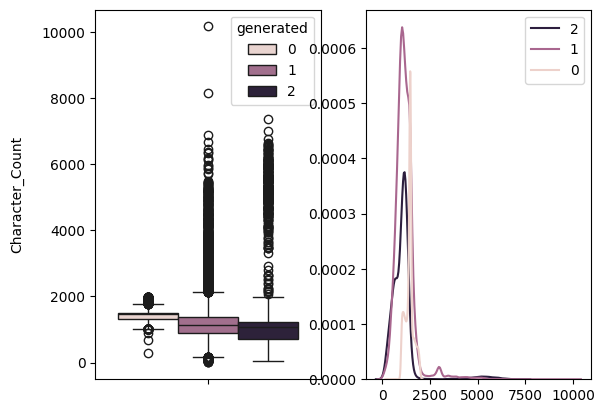

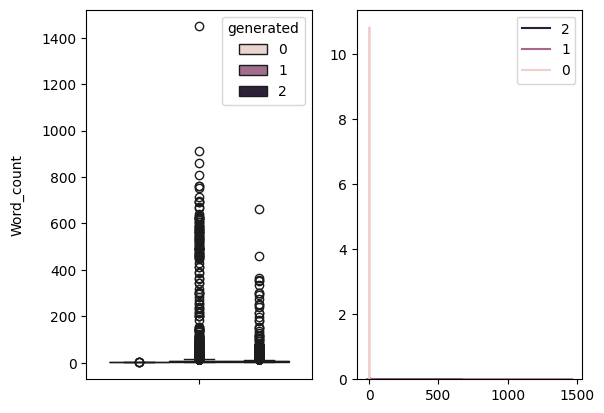

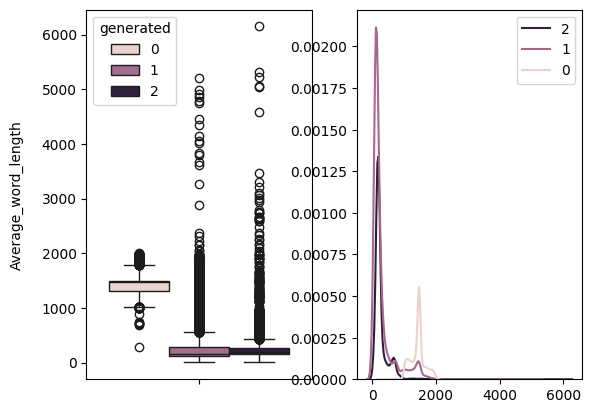

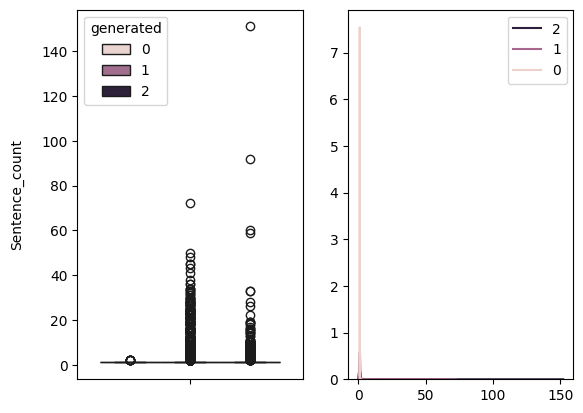

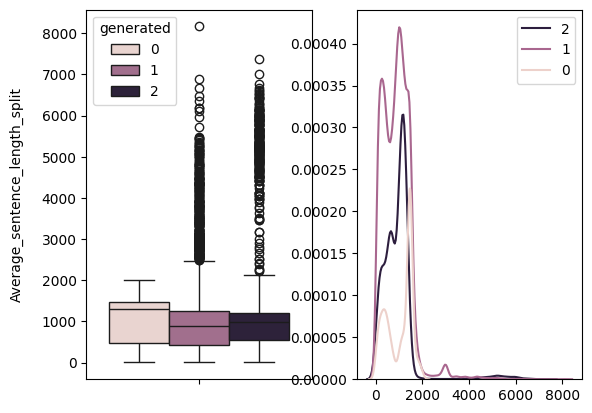

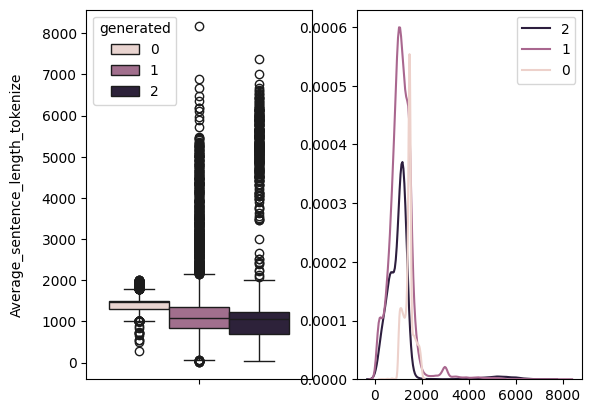

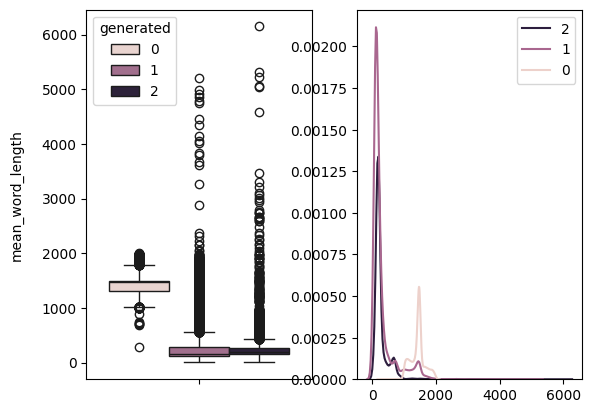

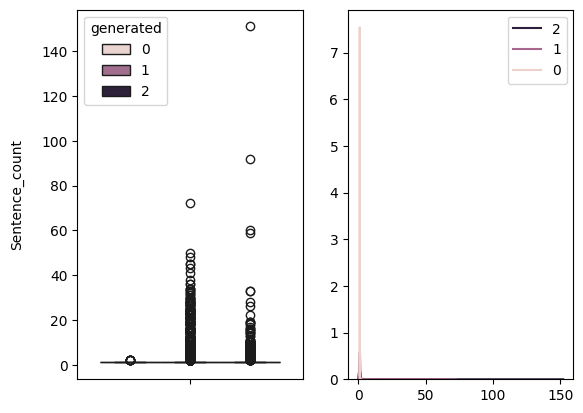

In [69]:
for feature in features:
    visualize(text_df,feature,'generated')

In [70]:
data=text_df
print(data['generated'].unique())

[2 1 0]


## Feature Engineering

### V - Text Complexity Features

	•	Unique Word Count: The number of unique words in each text sample, capturing vocabulary richness.
	•	Stop Word Count: The number of common stop words (like “the”, “is”, “and”) that can indicate writing style.
	•	Readability Scores: Metrics like Flesch-Kincaid or Gunning Fog scores, which can give insights into text complexity.

In [71]:
from nltk.corpus import stopwords
# stop_words = set(stopwords.words('english'))
stop_words = set(stopwords.words('chinese'))

text_df['unique_word_count'] = text_df['text'].apply(lambda x: len(set(x.split())))
text_df['stopword_count'] = text_df['text'].apply(lambda x: len([word for word in x.split() if word in stop_words]))

In [72]:
from nltk.corpus import stopwords
# stop_words = set(stopwords.words('english'))
stop_words = set(stopwords.words('chinese'))

text_df_1['unique_word_count'] = text_df_1['text'].apply(lambda x: len(set(x.split())))
text_df_1['stopword_count'] = text_df_1['text'].apply(lambda x: len([word for word in x.split() if word in stop_words]))

In [73]:
from nltk.corpus import stopwords
# stop_words = set(stopwords.words('english'))
stop_words = set(stopwords.words('chinese'))

text_df_2['unique_word_count'] = text_df_2['text'].apply(lambda x: len(set(x.split())))
text_df_2['stopword_count'] = text_df_2['text'].apply(lambda x: len([word for word in x.split() if word in stop_words]))

### ! - NGRAMS -TF-IDF (Term Frequency-Inverse Document Frequency)

TF-IDF is a way to weight words based on how frequently they appear across documents, emphasizing unique words. This is often more effective than raw word counts for feature extraction.

In [74]:
# Takes time
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=1000, ngram_range=(2, 6))
tfidf_features = tfidf.fit_transform(text_df['text'])

In [75]:
tfidf_features

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 64961 stored elements and shape (34133, 1000)>

### V - Sentiment Analysis

Many libraries, like TextBlob or VADER, provide sentiment analysis, yielding features like polarity (positive/negative sentiment) and subjectivity.

In [76]:
from textblob import TextBlob

text_df['polarity'] = text_df['text'].apply(lambda x: TextBlob(x).sentiment.polarity)
text_df['subjectivity'] = text_df['text'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

In [77]:
text_df.head()

,id,prompt_id,text,generated,Character_Count,Word_count,Average_word_length,Sentence_count,Average_sentence_length_split,Average_sentence_length_tokenize,mean_word_length,unique_word_count,stopword_count,polarity,subjectivity
25946,ChatGLM-News-Rewrite-ID-2818_LGT,2,在比逼格更有逼格的iPhone6热潮还未退去之前，苹果又开了一次大会。这一次他们做了更多的更...,2,6575,661,5.590015,151,35.331492,42.549669,5.590015,21,0,0.000000,0.000000
25804,ChatGLM-News-Rewrite-ID-2749_LGT,2,多知网6月30日消息，最近，语音评测技术公司消息频出，两周前网龙收购驰声科技的消息刚过，立思...,2,5894,184,31.016304,92,63.076087,63.076087,31.016304,98,0,0.000000,0.000000
17999,Qwen-Thesis-Rewrite-ID-393_HLT,1,I. Introduction This paper aims to provide an ...,1,10176,1449,6.010352,72,171.491525,140.125000,6.010352,896,0,0.098781,0.462876
28620,ChatGLM-Thesis-Rewrite-ID-1991_LGT,2,20世纪90年代以来，文化研究的热潮席卷了整个的文学研究领域。文化研究的出场，无疑是对文学研...,2,5462,150,35.200000,60,90.050000,90.050000,35.200000,7,0,0.000000,0.000000
29687,Baichuan-News-Rewrite-ID-2207_LGT,2,多知网3月23日消息，沪江联合创始人于杰在沪江“蚂蚁计划”发布会上表示，沪江近期进行了成立以...,2,5217,350,12.745714,59,85.966667,87.440678,12.745714,79,0,0.000000,0.000000


In [78]:
from textblob import TextBlob

text_df_1['polarity'] = text_df_1['text'].apply(lambda x: TextBlob(x).sentiment.polarity)
text_df_1['subjectivity'] = text_df_1['text'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

In [79]:
text_df_1.head()

,id,prompt_id,text,generated,Character_Count,Word_count,Average_word_length,Sentence_count,Average_sentence_length_split,Average_sentence_length_tokenize,mean_word_length,unique_word_count,stopword_count,polarity,subjectivity
0,testp1-0,-1,义乌景升工艺品有限公司：高品质油画定制专家，为您的空间增添艺术魅力在追求生活品质的今天，油画...,-1,949,19,49.000000,9,104.555556,104.555556,49.000000,19,0,0.0,0.0
1,testp1-1,-1,《法医学杂志》，2020年2月，第36卷，第1期 1 案例 1.1 简要案情 患者常某，男性...,-1,1277,24,52.250000,1,181.571429,1277.000000,52.250000,24,0,0.0,0.0
2,testp1-2,-1,上述研究显示，单部位或双部位的颅内硬脑膜下积液量较少，损伤主要由蛛网膜破裂引起，症状较轻；而...,-1,888,1,888.000000,1,176.800000,888.000000,888.000000,1,0,0.0,0.0
3,testp1-3,-1,户外速干防晒衣：高性价比尾货，无惧瑕疵，乐享UPF50专业防护！还在为高昂的品牌溢价买单吗？...,-1,960,11,86.363636,1,960.000000,960.000000,86.363636,11,0,0.0,0.0
4,testp1-4,-1,特别声明: 具体见颜色选项(本店自定义颜色可能与出厂标签表述不同属正常现象) 1. 默认中通...,-1,1312,157,7.363057,26,61.523810,49.500000,7.363057,142,1,0.0,0.0


In [80]:
from textblob import TextBlob

text_df_2['polarity'] = text_df_2['text'].apply(lambda x: TextBlob(x).sentiment.polarity)
text_df_2['subjectivity'] = text_df_2['text'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

In [81]:
text_df_2.head()

,id,prompt_id,text,generated,Character_Count,Word_count,Average_word_length,Sentence_count,Average_sentence_length_split,Average_sentence_length_tokenize,mean_word_length,unique_word_count,stopword_count,polarity,subjectivity
0,testp2-0,-1,邦士度眼镜成功通过ISO9001-2015质量管理体系认证 标志质量管理迈上新台阶近日，广州...,-1,923,2,461.000000,1,923.00,923.000000,461.000000,2,0,0.000000,0.000000
1,testp2-1,-1,法赫里·科鲁蒂尔克 法赫里·萨比特·科鲁蒂尔克（土耳其語：Fahri Sabit Korut...,-1,1030,59,16.474576,2,514.50,514.500000,16.474576,53,0,0.000000,0.000000
2,testp2-2,-1,在现代居家办公和学习的需求下，一款设计精美且功能实用的笔记本电脑桌显得尤为重要。宜宝诗品牌推...,-1,627,1,627.000000,1,313.00,627.000000,627.000000,1,0,0.000000,0.000000
3,testp2-3,-1,彼得·科斯格罗夫 彼得·約翰·科斯格罗夫爵士，AK，CVO，MC（英語：Sir Peter ...,-1,897,42,20.380952,7,111.25,127.285714,20.380952,39,0,0.016667,0.166667
4,testp2-4,-1,五人斗地主：双倍刺激的扑克新玩法在传统斗地主风靡全国多年后，一种更具挑战性的变体——五人斗地...,-1,681,8,84.250000,1,681.00,681.000000,84.250000,8,0,0.000000,0.000000


In [82]:
text_df.to_csv('./text_df_2024_11_25_NUM2-nlpcc.csv', index=False, escapechar='\\')

In [83]:
text_df_1.to_csv('./text_df_1_2024_11_25_NUM2-nlpcc.csv', index=False, escapechar='\\')

In [84]:
text_df_2.to_csv('./text_df_2_2024_11_25_NUM2-nlpcc.csv', index=False, escapechar='\\')

### X - Part-of-Speech (POS) Tagging

POS tagging can help identify patterns in language use, such as the frequency of nouns, verbs, or adjectives. This is useful for certain NLP tasks like author profiling or style analysis.

In [85]:
def pos_counts(text):
    tokens = nltk.word_tokenize(text)
    pos_tags = nltk.pos_tag(tokens)
    pos_counts = nltk.FreqDist(tag for _, tag in pos_tags)
    return pos_counts

text_df['pos_counts'] = text_df['text'].apply(pos_counts)

### X - Named Entity Recognition (NER)

NER identifies entities like people, places, and organizations, which can be informative for text classification. The spaCy library provides easy-to-use NER.

直接下载（推荐）

在终端执行：

In [ ]:
# !python -m spacy download en_core_web_sm

In [ ]:
# !python -m spacy download zh_core_web_sm

In [58]:
import spacy
# nlp = spacy.load("en_core_web_sm")
nlp = spacy.load("zh_core_web_sm")

def extract_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

text_df['entities'] = text_df['text'].apply(extract_entities)

### ! - Word Embeddings (e.g., Word2Vec, GloVe)

Pre-trained word embeddings capture semantic meaning. Averaging word embeddings in a sentence or using pooled embeddings (like BERT) can create dense, informative features.

In [59]:
# Example using Word2Vec (use GloVe or FastText similarly)
from gensim.models import Word2Vec

# Tokenize text data
sentences = text_df['text'].apply(lambda x: x.split())
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1)

# Generate embedding for each document by averaging word embeddings
def average_embedding(text):
    words = text.split()
    return sum(w2v_model.wv[word] for word in words if word in w2v_model.wv) / len(words)

text_df['avg_word2vec'] = text_df['text'].apply(average_embedding)

### X - Topic Modeling (LDA or NMF)

Latent Dirichlet Allocation (LDA) and Non-negative Matrix Factorization (NMF) can identify topics in text, converting documents into a fixed number of topics.

In [60]:
# 15m+
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_features=1000)
dtm = vectorizer.fit_transform(text_df['text'])

lda = LatentDirichletAllocation(n_components=5)
topic_matrix = lda.fit_transform(dtm)

In [61]:
print(topic_matrix)

[[6.45161354e-03 9.74193547e-01 6.45161306e-03 6.45161338e-03
  6.45161309e-03]
 [4.17107988e-03 4.17467044e-03 4.17872931e-03 4.17442646e-03
  9.83301094e-01]
 [9.97841631e-01 5.41114358e-04 5.39083596e-04 5.39087887e-04
  5.39083601e-04]
 ...
 [3.33350229e-02 3.33735820e-02 8.66159078e-01 3.33590790e-02
  3.37732386e-02]
 [2.00877730e-02 2.03301921e-02 8.05759475e-01 2.00399361e-02
  1.33782624e-01]
 [4.00001175e-02 4.00001028e-02 4.00000290e-02 4.00000836e-02
  8.39999667e-01]]


### ! - Bag-of-Words (BOW)

BOW is a basic yet powerful representation of text as sparse vectors. You can limit the vocabulary size to manage feature count, as shown previously.

In [62]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=1000, ngram_range=(2, 6))
bow_features = bow.fit_transform(text_df['text'])

In [63]:
print(bow_features)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 64961 stored elements and shape (34133, 1000)>
  Coords	Values
  (2, 91)	5
  (2, 112)	6
  (2, 142)	4
  (6, 616)	1
  (6, 682)	1
  (6, 168)	1
  (6, 93)	1
  (6, 38)	1
  (6, 366)	1
  (6, 940)	1
  (6, 62)	1
  (6, 226)	1
  (6, 677)	1
  (6, 966)	1
  (6, 875)	1
  (6, 934)	1
  (6, 382)	1
  (6, 466)	1
  (6, 558)	1
  (6, 919)	1
  (6, 424)	1
  (6, 694)	1
  (6, 617)	1
  (6, 683)	1
  (6, 169)	1
  :	:
  (33963, 970)	1
  (33963, 880)	1
  (33963, 939)	1
  (33963, 388)	1
  (33963, 473)	1
  (33969, 32)	1
  (33999, 56)	1
  (34002, 722)	6
  (34002, 721)	2
  (34002, 817)	4
  (34009, 700)	1
  (34010, 700)	1
  (34011, 700)	1
  (34017, 349)	1
  (34029, 694)	1
  (34038, 700)	1
  (34045, 701)	1
  (34053, 701)	1
  (34079, 702)	1
  (34082, 700)	1
  (34099, 722)	1
  (34099, 349)	1
  (34106, 702)	1
  (34107, 700)	1
  (34113, 722)	1


### V -Keyword Extraction

Extract key phrases or terms that capture the main topics or ideas in each text. Techniques like TF-IDF, RAKE (Rapid Automatic Keyword Extraction), or spaCy’s noun chunks can be used.

In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer
# 读取：
with open("stopwords.txt", "r", encoding="utf-8") as f:
    stopwords = [line.strip() for line in f]

# tfidf = TfidfVectorizer(max_features=10, stop_words="english")
tfidf = TfidfVectorizer(max_features=10, stop_words=stopwords)
keywords_matrix = tfidf.fit_transform(text_df['text'])
text_df['keywords'] = [tfidf.inverse_transform(doc) for doc in keywords_matrix]

In [65]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# # Initialize TfidfVectorizer with n-gram range
# tfidf_vectorizer = TfidfVectorizer(ngram_range=(2, 3))  # Bigrams and Trigrams

# # Fit and transform the text data
# X_tfidf = tfidf_vectorizer.fit_transform(text_df['text'])

# # Create a DataFrame from the resulting matrix for easy viewing
# tfidf_ngram_features = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# print(tfidf_ngram_features)

#### heatmap

In [66]:
cols_to_drop = ['id', 'prompt_id', 'text']
corr_columns = text_df.columns.drop(cols_to_drop)
correlations = text_df[corr_columns].corr(numeric_only=True)

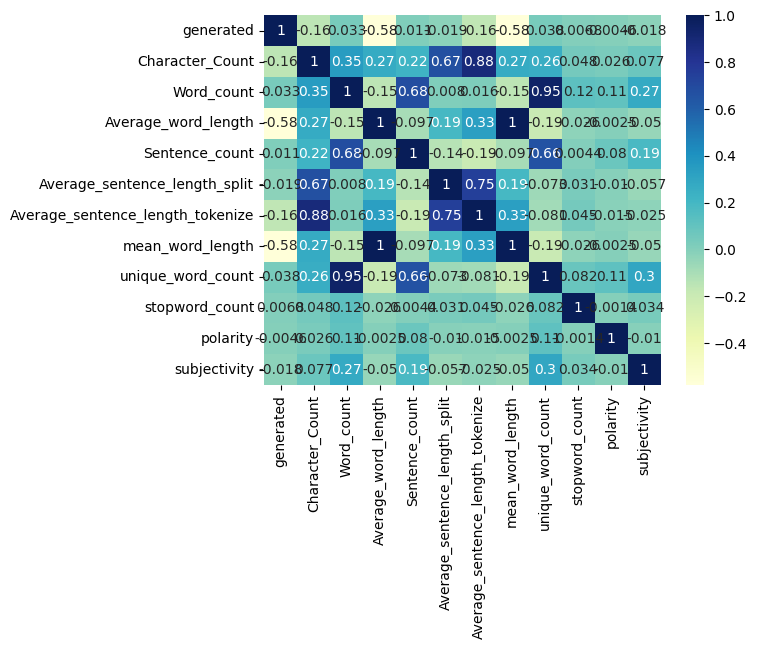

In [67]:
dataplot = sns.heatmap(correlations, cmap="YlGnBu", annot=True)

# Model

In [68]:
# data = pd.read_csv('https://media.githubusercontent.com/media/liron7722/AI-Generated-Text-Detector/refs/heads/Production/data/text_df_2024_11_14.csv')
data = pd.read_csv('./text_df_2024_11_25_NUM2-nlpcc.csv')
data.head()

,id,prompt_id,text,generated,Character_Count,Word_count,Average_word_length,Sentence_count,Average_sentence_length_split,Average_sentence_length_tokenize,mean_word_length,unique_word_count,stopword_count,polarity,subjectivity
0,ChatGLM-News-Rewrite-ID-2818_LGT,2,在比逼格更有逼格的iPhone6热潮还未退去之前，苹果又开了一次大会。这一次他们做了更多的更...,2,6575,661,5.590015,151,35.331492,42.549669,5.590015,21,0,0.000000,0.000000
1,ChatGLM-News-Rewrite-ID-2749_LGT,2,多知网6月30日消息，最近，语音评测技术公司消息频出，两周前网龙收购驰声科技的消息刚过，立思...,2,5894,184,31.016304,92,63.076087,63.076087,31.016304,98,0,0.000000,0.000000
2,Qwen-Thesis-Rewrite-ID-393_HLT,1,I. Introduction This paper aims to provide an ...,1,10176,1449,6.010352,72,171.491525,140.125000,6.010352,896,0,0.098781,0.462876
3,ChatGLM-Thesis-Rewrite-ID-1991_LGT,2,20世纪90年代以来，文化研究的热潮席卷了整个的文学研究领域。文化研究的出场，无疑是对文学研...,2,5462,150,35.200000,60,90.050000,90.050000,35.200000,7,0,0.000000,0.000000
4,Baichuan-News-Rewrite-ID-2207_LGT,2,多知网3月23日消息，沪江联合创始人于杰在沪江“蚂蚁计划”发布会上表示，沪江近期进行了成立以...,2,5217,350,12.745714,59,85.966667,87.440678,12.745714,79,0,0.000000,0.000000


## class Model

In [102]:
class Model:
    def __init__(self, model, X, y, scaler=None, test_size=0.2, random_state=42, wandb_project=None):
        self.model = model
        self.X = X
        self.y = y
        self.scaler = scaler
        self.test_size = test_size
        self.random_state = random_state
        self.history = {}

        # Splitting the data
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=self.test_size, random_state=self.random_state
        )

        # W&B initialization
        self.wandb_project = wandb_project
        self.wandb_run = None
        if self.wandb_project:
            self.wandb_run = wandb.init(project=self.wandb_project, config={"random_state": self.random_state})

    def _normalize(self):
        """Normalize the data if a scaler is provided."""
        if self.scaler:
            self.scaler = self.scaler.fit(self.X_train)
            self.X_train = self.scaler.transform(self.X_train)
            self.X_test = self.scaler.transform(self.X_test)

    def _train(self):
        """Train the model."""
        self.model.fit(self.X_train, self.y_train)
        self.history['model'] = str(self.model)

    def _evaluate(self):
        """Evaluate the model."""
        self.y_pred = self.model.predict(self.X_test)
        self.accuracy = accuracy_score(self.y_test, self.y_pred)
        self.report = classification_report(self.y_test, self.y_pred, output_dict=True)
        self.confusion = confusion_matrix(self.y_test, self.y_pred)

        if self.wandb_run:
            # Log metrics to W&B
            wandb.log({
                "accuracy": self.accuracy,
                "classification_report": self.report,
            })

            # Log confusion matrix as a heatmap
            wandb.log({
                "confusion_matrix": wandb.Image(self._create_confusion_matrix_figure())
            })

    def _create_confusion_matrix_figure(self):
        """Create a matplotlib figure for the confusion matrix."""
        plt.figure(figsize=(8, 6))
        sns.heatmap(self.confusion, annot=True, fmt='d', cmap='Blues', xticklabels=True, yticklabels=True)
        plt.title(f'Confusion Matrix\nAccuracy: {self.accuracy:.2f}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()
        return plt

    def save_model(self, filepath="model.pkl"):
        """Save the trained model as a pickle file."""
        joblib.dump(self.model, filepath)
        if self.scaler:
           scaler_path = filepath.replace(".pkl", "_scaler.pkl")
           joblib.dump(self.scaler, scaler_path)
        print(f"Model saved to {filepath}")

        if self.wandb_run:
            # Upload the saved model to W&B
            wandb.save(filepath)

    def run(self):
        """Run the pipeline: Normalize, Train, Evaluate."""
        self._normalize()
        self._train()
        self._evaluate()

    def finalize(self):
        """Finish W&B run if initialized."""
        if self.wandb_run:
            self.wandb_run.finish()

    def get_data(self):
        """
        Return evaluation data.
        - Accuracy
        - Classification Report
        - Confusion Matrix
        """
        return {
            'accuracy': self.accuracy,
            'classification_report': self.report,
            'confusion_matrix': self.confusion,
        }


## class ModelManager

In [103]:
class ModelManager:
    def __init__(self, models, X, y, scaler=None, test_size=0.2, random_state=42, wandb_project=None):
        self.models = models
        self.X = X
        self.y = y
        self.scaler = scaler
        self.test_size = test_size
        self.random_state = random_state
        self.results_df = None
        self.model_instances = []
        self.wandb_project = wandb_project

        if wandb_project:
            wandb.init(project=wandb_project)

    def run_all(self):
        """Train, evaluate, and collect results for all models."""
        results = []

        for name, model in self.models.items():
            # Create and run a Model instance
            model_instance = Model(model, self.X, self.y, scaler=self.scaler, test_size=self.test_size,
                                   random_state=self.random_state, wandb_project=self.wandb_project)
            model_instance.run()
            self.model_instances.append(model_instance)

            # Collect metrics
            results.append({
                'Model': name,
                'Accuracy': model_instance.accuracy,
                'Precision (Weighted)': model_instance.report['weighted avg']['precision'],
                'Recall (Weighted)': model_instance.report['weighted avg']['recall'],
                'F1-Score (Weighted)': model_instance.report['weighted avg']['f1-score']
            })

            # Save the model
            filepath = f"{name.replace(' ', '_').lower()}_model.pkl"
            model_instance.save_model(filepath)

        # Save results to a DataFrame
        self.results_df = pd.DataFrame(results)

        # Log comparison graph to W&B
        if self.wandb_project:
            self._log_comparison_to_wandb()

    def _log_comparison_to_wandb(self):
        """Log a comparison graph to W&B."""
        metrics = ['Accuracy', 'Precision (Weighted)', 'Recall (Weighted)', 'F1-Score (Weighted)']
        comparison_data = []

        # for _, row in self.results_df.iterrows():
        #     for metric in metrics:
        #         comparison_data.append({"Model": row["Model"], "Metric": metric, "Score": row[metric]})

        # wandb.log({
        #     "comparison_graph": wandb.plot.bar(
        #         pd.DataFrame(comparison_data),
        #         x="Metric",
        #         y="Score",
        #         title="Model Performance Comparison",
        #         keys="Model"
        #     )
        # })
        
        for _, row in self.results_df.iterrows():
            for metric in metrics:
                comparison_data.append([
                    row["Model"],
                    metric,
                    row[metric]
                ])

        table = wandb.Table(
            data=comparison_data,
            columns=["Model", "Metric", "Score"]
        )
    
        wandb.log({
            "comparison_graph": wandb.plot.bar(
                table,
                "Metric",
                "Score",
                title="Model Performance Comparison"
            )
        })
    def visualize_comparison(self):
        """Visualize model performance comparison."""
    
        metrics = [
            'Accuracy',
            'Precision (Weighted)',
            'Recall (Weighted)',
            'F1-Score (Weighted)'
        ]
    
        df_plot = self.results_df.set_index("Model")[metrics]
    
        plt.figure(figsize=(10, 6))
        df_plot.plot(kind='bar')
    
        plt.title("Model Performance Comparison")
        plt.ylabel("Score")
        plt.xticks(rotation=45)
    
        plt.tight_layout()
        plt.show()


## models run

X:        Character_Count  Word_count  Average_word_length  Sentence_count  \
0                 6575         661             5.590015             151   
1                 5894         184            31.016304              92   
2                10176        1449             6.010352              72   
3                 5462         150            35.200000              60   
4                 5217         350            12.745714              59   
...                ...         ...                  ...             ...   
34128             1558           5           309.800000               1   
34129             1244           4           309.750000               1   
34130             1245           4           309.750000               1   
34131             1556           5           309.600000               1   
34132              310           1           310.000000               1   

       Average_sentence_length_split  Average_sentence_length_tokenize  \
0                     

accuracy,▁
accuracy,0.65871


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Model saved to logistic_regression_model.pkl


accuracy,▁
accuracy,0.66237


...

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Model saved to xgboost_model.pkl


accuracy,▁
accuracy,0.78219


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Model saved to svm_model.pkl


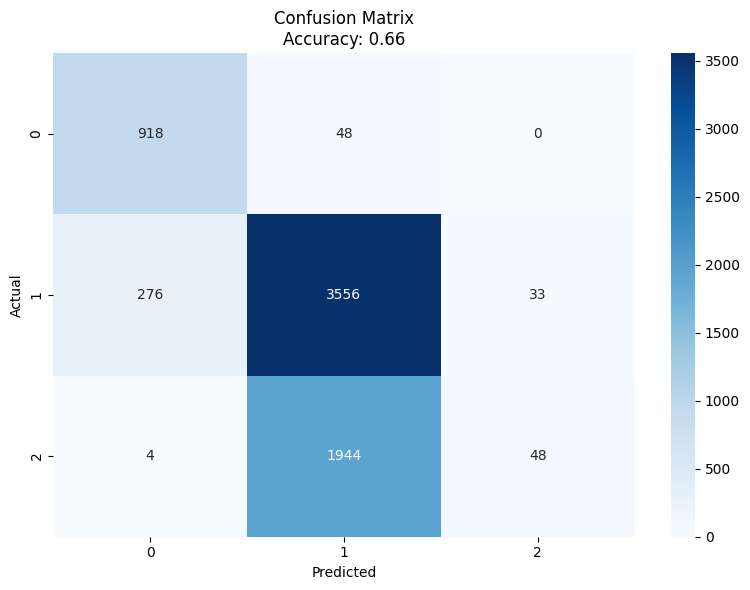

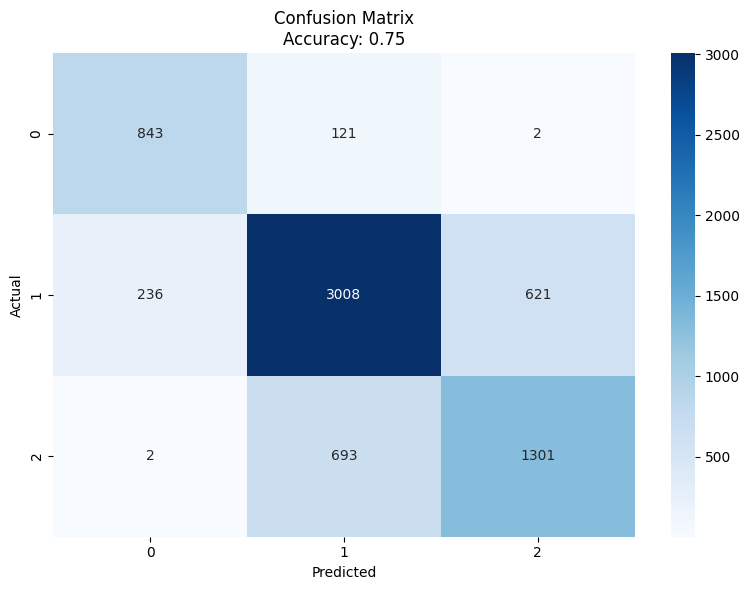

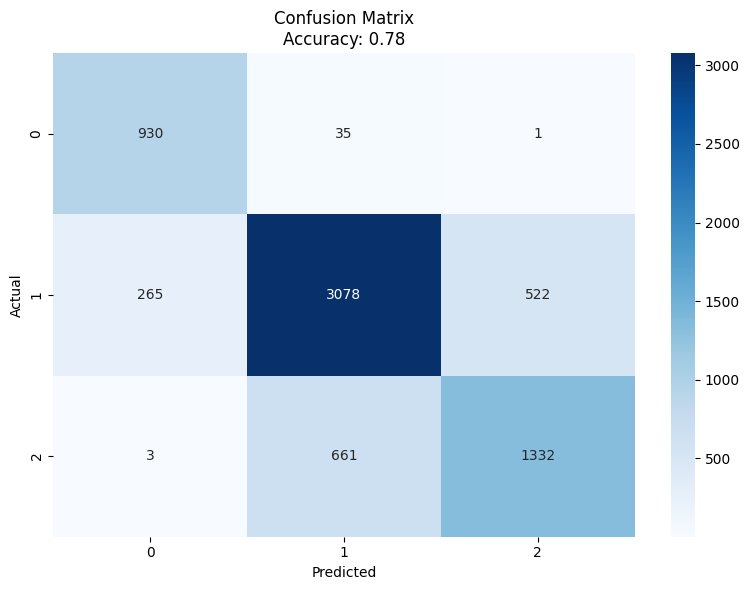

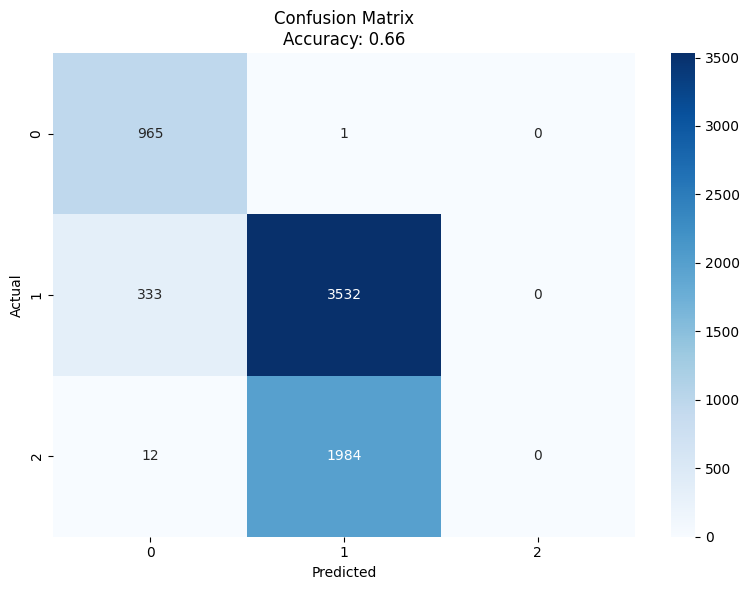

<Figure size 1000x600 with 0 Axes>

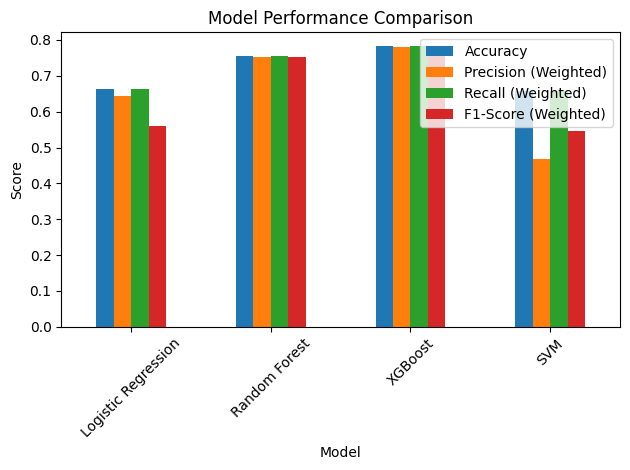

                 Model  Accuracy  Precision (Weighted)  Recall (Weighted)  \
0  Logistic Regression  0.662370              0.644546           0.662370   
1        Random Forest  0.754651              0.753603           0.754651   
2              XGBoost  0.782188              0.781509           0.782188   
3                  SVM  0.658708              0.466674           0.658708   

   F1-Score (Weighted)  
0             0.561307  
1             0.753678  
2             0.780098  
3             0.546247  


In [104]:
# Load dataset
# from sklearn.datasets import load_iris
# data = load_iris()
# X, y = data.data, data.target

target_col = 'generated'
# cols_to_drop = [target_col, 'prompt_id', 'id', 'text', 'pos_counts', 'keywords']
cols_to_drop = [target_col, 'prompt_id', 'id','text' ]
cols = data.columns.drop(cols_to_drop)
X = data[cols]
y = data[target_col]

print("X:", X)
print("y:", y)
# Models to compare

models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'Random Forest': RandomForestClassifier(),
    # 'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    # 如果是三分类任务：
    'XGBoost': XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss"
    ),
    'SVM': SVC(kernel='linear')
}

# Initialize ModelManager
manager = ModelManager(models, X, y, scaler=StandardScaler(), wandb_project="AI-Generated-Text-Detector-Project")

# Run all models
manager.run_all()

# Visualize the comparison
manager.visualize_comparison()

# Access the results DataFrame
# results = manager.get_results()
# print(results)

# # Access individual model instances
# instances = manager.get_model_instances()
# for instance in instances:
#     print(instance.get_data())

# 建议

# 训练结束后先检查：
df_results = manager.results_df
print(manager.results_df)

## results

In [105]:
df_results

,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted)
0,Logistic Regression,0.662370,0.644546,0.662370,0.561307
1,Random Forest,0.754651,0.753603,0.754651,0.753678
2,XGBoost,0.782188,0.781509,0.782188,0.780098
3,SVM,0.658708,0.466674,0.658708,0.546247


测试脚本（XGBoost示例）

testp1

In [86]:
import pandas as pd
import joblib
import json

# =====================
# 1. 读取测试集
# =====================
test_df = pd.read_csv("text_df_1_2024_11_25_NUM2-nlpcc.csv")

# 保存原始ID
ids = test_df["id"].tolist()

# =====================
# 2. 构造特征
# =====================
cols_to_drop = [
    'generated',
    'prompt_id',
    'id',
    'text'
]

X_test = test_df.drop(columns=cols_to_drop)

# =====================
# 3. 加载Scaler
# =====================
scaler = joblib.load("xgboost_model_scaler.pkl")

X_test = scaler.transform(X_test)

# =====================
# 4. 加载模型
# =====================
model = joblib.load("xgboost_model.pkl")

# =====================
# 5. 预测
# =====================
preds = model.predict(X_test)

print(preds[:10])

# =====================
# 6. 生成提交文件
# =====================
submission = []

for sample_id, pred in zip(ids, preds):
    submission.append({
        "id": str(sample_id),
        "label": int(pred)
    })

with open("Submission/XGBoost/testp1/prediction.json", "w", encoding="utf-8") as f:
    json.dump(
        submission,
        f,
        ensure_ascii=False,
        indent=2
    )

print(f"Saved {len(submission)} predictions to Submission/XGBoost/testp1/prediction.json")

[1 1 1 1 1 1 1 1 1 1]
Saved 3600 predictions to Submission/XGBoost/testp1/prediction.json


In [87]:
import zipfile

with zipfile.ZipFile("Submission/XGBoost/testp1/submission.zip", "w", zipfile.ZIP_DEFLATED) as z:
    z.write("Submission/XGBoost/testp1/prediction.json")

print("Submission/XGBoost/testp1/submission.zip created")

Submission/XGBoost/testp1/submission.zip created


In [88]:
import zipfile

with zipfile.ZipFile("Submission/XGBoost/testp1/prediction.zip", "w", zipfile.ZIP_DEFLATED) as z:
    z.write("Submission/XGBoost/testp1/prediction.json", "prediction.json")

print("Submission/XGBoost/testp1/prediction.zip created")

Submission/XGBoost/testp1/prediction.zip created


testp2

In [89]:
import pandas as pd
import joblib
import json

# =====================
# 1. 读取测试集
# =====================
test_df = pd.read_csv("text_df_2_2024_11_25_NUM2-nlpcc.csv")

# 保存原始ID
ids = test_df["id"].tolist()

# =====================
# 2. 构造特征
# =====================
cols_to_drop = [
    'generated',
    'prompt_id',
    'id',
    'text'
]

X_test = test_df.drop(columns=cols_to_drop)

# =====================
# 3. 加载Scaler
# =====================
scaler = joblib.load("xgboost_model_scaler.pkl")

X_test = scaler.transform(X_test)

# =====================
# 4. 加载模型
# =====================
model = joblib.load("xgboost_model.pkl")

# =====================
# 5. 预测
# =====================
preds = model.predict(X_test)

print(preds[:10])

# =====================
# 6. 生成提交文件
# =====================
submission = []

for sample_id, pred in zip(ids, preds):
    submission.append({
        "id": str(sample_id),
        "label": int(pred)
    })

with open("Submission/XGBoost/testp2/prediction.json", "w", encoding="utf-8") as f:
    json.dump(
        submission,
        f,
        ensure_ascii=False,
        indent=2
    )

print(f"Saved {len(submission)} predictions to Submission/XGBoost/testp2/prediction.json")

[1 1 2 1 1 2 1 1 2 1]
Saved 1152 predictions to Submission/XGBoost/testp2/prediction.json


In [90]:
import zipfile

with zipfile.ZipFile("Submission/XGBoost/testp2/prediction.zip", "w", zipfile.ZIP_DEFLATED) as z:
    z.write("Submission/XGBoost/testp2/prediction.json", "prediction.json")

print("Submission/XGBoost/testp2/prediction.zip created")

Submission/XGBoost/testp2/prediction.zip created


Logistic_Regression

testp1

In [91]:
import pandas as pd
import joblib
import json

# =====================
# 1. 读取测试集
# =====================
test_df = pd.read_csv("text_df_1_2024_11_25_NUM2-nlpcc.csv")

# 保存原始ID
ids = test_df["id"].tolist()

# =====================
# 2. 构造特征
# =====================
cols_to_drop = [
    'generated',
    'prompt_id',
    'id',
    'text'
]

X_test = test_df.drop(columns=cols_to_drop)

# =====================
# 3. 加载Scaler
# =====================
scaler = joblib.load("logistic_regression_model_scaler.pkl")

X_test = scaler.transform(X_test)

# =====================
# 4. 加载模型
# =====================
model = joblib.load("logistic_regression_model.pkl")

# =====================
# 5. 预测
# =====================
preds = model.predict(X_test)

print(preds[:10])

# =====================
# 6. 生成提交文件
# =====================
submission = []

for sample_id, pred in zip(ids, preds):
    submission.append({
        "id": str(sample_id),
        "label": int(pred)
    })

with open("Submission/Logistic_Regression/testp1/prediction.json", "w", encoding="utf-8") as f:
    json.dump(
        submission,
        f,
        ensure_ascii=False,
        indent=2
    )

print(f"Saved {len(submission)} predictions to Submission/Logistic_Regression/testp1/prediction.json")

[1 1 1 1 1 1 1 1 1 1]
Saved 3600 predictions to Submission/Logistic_Regression/testp1/prediction.json


In [92]:
import zipfile

with zipfile.ZipFile("Submission/Logistic_Regression/testp1/submission.zip", "w", zipfile.ZIP_DEFLATED) as z:
    z.write("Submission/Logistic_Regression/testp1/prediction.json")

print("Submission/Logistic_Regression/testp1/submission.zip created")

Submission/Logistic_Regression/testp1/submission.zip created


In [93]:
import zipfile

with zipfile.ZipFile("Submission/Logistic_Regression/testp1/prediction.zip", "w", zipfile.ZIP_DEFLATED) as z:
    z.write("Submission/Logistic_Regression/testp1/prediction.json", "prediction.json")

print("Submission/Logistic_Regression/testp1/prediction.zip created")

Submission/Logistic_Regression/testp1/prediction.zip created


testp2

In [94]:
import pandas as pd
import joblib
import json

# =====================
# 1. 读取测试集
# =====================
test_df = pd.read_csv("text_df_2_2024_11_25_NUM2-nlpcc.csv")

# 保存原始ID
ids = test_df["id"].tolist()

# =====================
# 2. 构造特征
# =====================
cols_to_drop = [
    'generated',
    'prompt_id',
    'id',
    'text'
]

X_test = test_df.drop(columns=cols_to_drop)

# =====================
# 3. 加载Scaler
# =====================
scaler = joblib.load("logistic_regression_model_scaler.pkl")

X_test = scaler.transform(X_test)

# =====================
# 4. 加载模型
# =====================
model = joblib.load("logistic_regression_model.pkl")

# =====================
# 5. 预测
# =====================
preds = model.predict(X_test)

print(preds[:10])

# =====================
# 6. 生成提交文件
# =====================
submission = []

for sample_id, pred in zip(ids, preds):
    submission.append({
        "id": str(sample_id),
        "label": int(pred)
    })

with open("Submission/Logistic_Regression/testp2/prediction.json", "w", encoding="utf-8") as f:
    json.dump(
        submission,
        f,
        ensure_ascii=False,
        indent=2
    )

print(f"Saved {len(submission)} predictions to Submission/Logistic_Regression/testp2/prediction.json")

[1 1 1 1 1 1 1 0 1 1]
Saved 1152 predictions to Submission/Logistic_Regression/testp2/prediction.json


In [95]:
import zipfile

with zipfile.ZipFile("Submission/Logistic_Regression/testp2/prediction.zip", "w", zipfile.ZIP_DEFLATED) as z:
    z.write("Submission/Logistic_Regression/testp2/prediction.json", "prediction.json")

print("Submission/Logistic_Regression/testp2/prediction.zip created")

Submission/Logistic_Regression/testp2/prediction.zip created


SVM

testp1

In [96]:
import pandas as pd
import joblib
import json

# =====================
# 1. 读取测试集
# =====================
test_df = pd.read_csv("text_df_1_2024_11_25_NUM2-nlpcc.csv")

# 保存原始ID
ids = test_df["id"].tolist()

# =====================
# 2. 构造特征
# =====================
cols_to_drop = [
    'generated',
    'prompt_id',
    'id',
    'text'
]

X_test = test_df.drop(columns=cols_to_drop)

# =====================
# 3. 加载Scaler
# =====================
scaler = joblib.load("svm_model_scaler.pkl")

X_test = scaler.transform(X_test)

# =====================
# 4. 加载模型
# =====================
model = joblib.load("svm_model.pkl")

# =====================
# 5. 预测
# =====================
preds = model.predict(X_test)

print(preds[:10])

# =====================
# 6. 生成提交文件
# =====================
submission = []

for sample_id, pred in zip(ids, preds):
    submission.append({
        "id": str(sample_id),
        "label": int(pred)
    })

with open("Submission/SVM/testp1/prediction.json", "w", encoding="utf-8") as f:
    json.dump(
        submission,
        f,
        ensure_ascii=False,
        indent=2
    )

print(f"Saved {len(submission)} predictions to Submission/SVM/testp1/prediction.json")

[1 1 0 1 1 1 1 1 1 1]
Saved 3600 predictions to Submission/SVM/testp1/prediction.json


In [97]:
import zipfile

with zipfile.ZipFile("Submission/SVM/testp1/submission.zip", "w", zipfile.ZIP_DEFLATED) as z:
    z.write("Submission/SVM/testp1/prediction.json")

print("Submission/SVM/testp1/submission.zip created")

Submission/SVM/testp1/submission.zip created


In [98]:
import zipfile

with zipfile.ZipFile("Submission/SVM/testp1/prediction.zip", "w", zipfile.ZIP_DEFLATED) as z:
    z.write("Submission/SVM/testp1/prediction.json", "prediction.json")

print("Submission/SVM/testp1/prediction.zip created")

Submission/SVM/testp1/prediction.zip created


testp2

In [99]:
import pandas as pd
import joblib
import json

# =====================
# 1. 读取测试集
# =====================
test_df = pd.read_csv("text_df_2_2024_11_25_NUM2-nlpcc.csv")

# 保存原始ID
ids = test_df["id"].tolist()

# =====================
# 2. 构造特征
# =====================
cols_to_drop = [
    'generated',
    'prompt_id',
    'id',
    'text'
]

X_test = test_df.drop(columns=cols_to_drop)

# =====================
# 3. 加载Scaler
# =====================
scaler = joblib.load("svm_model_scaler.pkl")

X_test = scaler.transform(X_test)

# =====================
# 4. 加载模型
# =====================
model = joblib.load("svm_model.pkl")

# =====================
# 5. 预测
# =====================
preds = model.predict(X_test)

print(preds[:10])

# =====================
# 6. 生成提交文件
# =====================
submission = []

for sample_id, pred in zip(ids, preds):
    submission.append({
        "id": str(sample_id),
        "label": int(pred)
    })

with open("Submission/SVM/testp2/prediction.json", "w", encoding="utf-8") as f:
    json.dump(
        submission,
        f,
        ensure_ascii=False,
        indent=2
    )

print(f"Saved {len(submission)} predictions to Submission/SVM/testp2/prediction.json")

[1 1 1 1 1 1 1 0 1 1]
Saved 1152 predictions to Submission/SVM/testp2/prediction.json


In [100]:
import zipfile

with zipfile.ZipFile("Submission/SVM/testp2/prediction.zip", "w", zipfile.ZIP_DEFLATED) as z:
    z.write("Submission/SVM/testp2/prediction.json", "prediction.json")

print("Submission/SVM/testp2/prediction.zip created")

Submission/SVM/testp2/prediction.zip created


Random_Forest

testp1

In [101]:
import pandas as pd
import joblib
import json

# =====================
# 1. 读取测试集
# =====================
test_df = pd.read_csv("text_df_1_2024_11_25_NUM2-nlpcc.csv")

# 保存原始ID
ids = test_df["id"].tolist()

# =====================
# 2. 构造特征
# =====================
cols_to_drop = [
    'generated',
    'prompt_id',
    'id',
    'text'
]

X_test = test_df.drop(columns=cols_to_drop)

# =====================
# 3. 加载Scaler
# =====================
scaler = joblib.load("random_forest_model_scaler.pkl")

X_test = scaler.transform(X_test)

# =====================
# 4. 加载模型
# =====================
model = joblib.load("random_forest_model.pkl")

# =====================
# 5. 预测
# =====================
preds = model.predict(X_test)

print(preds[:10])

# =====================
# 6. 生成提交文件
# =====================
submission = []

for sample_id, pred in zip(ids, preds):
    submission.append({
        "id": str(sample_id),
        "label": int(pred)
    })

with open("Submission/Random_Forest/testp1/prediction.json", "w", encoding="utf-8") as f:
    json.dump(
        submission,
        f,
        ensure_ascii=False,
        indent=2
    )

print(f"Saved {len(submission)} predictions to Submission/Random_Forest/testp1/prediction.json")

[1 1 1 1 1 1 1 1 1 1]
Saved 3600 predictions to Submission/Random_Forest/testp1/prediction.json


In [102]:
import zipfile

with zipfile.ZipFile("Submission/Random_Forest/testp1/submission.zip", "w", zipfile.ZIP_DEFLATED) as z:
    z.write("Submission/Random_Forest/testp1/prediction.json")

print("Submission/Random_Forest/testp1/submission.zip created")

Submission/Random_Forest/testp1/submission.zip created


In [103]:
import zipfile

with zipfile.ZipFile("Submission/Random_Forest/testp1/prediction.zip", "w", zipfile.ZIP_DEFLATED) as z:
    z.write("Submission/Random_Forest/testp1/prediction.json", "prediction.json")

print("Submission/Random_Forest/testp1/prediction.zip created")

Submission/Random_Forest/testp1/prediction.zip created


testp2

In [104]:
import pandas as pd
import joblib
import json

# =====================
# 1. 读取测试集
# =====================
test_df = pd.read_csv("text_df_2_2024_11_25_NUM2-nlpcc.csv")

# 保存原始ID
ids = test_df["id"].tolist()

# =====================
# 2. 构造特征
# =====================
cols_to_drop = [
    'generated',
    'prompt_id',
    'id',
    'text'
]

X_test = test_df.drop(columns=cols_to_drop)

# =====================
# 3. 加载Scaler
# =====================
scaler = joblib.load("random_forest_model_scaler.pkl")

X_test = scaler.transform(X_test)

# =====================
# 4. 加载模型
# =====================
model = joblib.load("random_forest_model.pkl")

# =====================
# 5. 预测
# =====================
preds = model.predict(X_test)

print(preds[:10])

# =====================
# 6. 生成提交文件
# =====================
submission = []

for sample_id, pred in zip(ids, preds):
    submission.append({
        "id": str(sample_id),
        "label": int(pred)
    })

with open("Submission/Random_Forest/testp2/prediction.json", "w", encoding="utf-8") as f:
    json.dump(
        submission,
        f,
        ensure_ascii=False,
        indent=2
    )

print(f"Saved {len(submission)} predictions to Submission/Random_Forest/testp2/prediction.json")

[1 1 2 1 1 1 1 1 2 1]
Saved 1152 predictions to Submission/Random_Forest/testp2/prediction.json


In [105]:
import zipfile

with zipfile.ZipFile("Submission/Random_Forest/testp2/prediction.zip", "w", zipfile.ZIP_DEFLATED) as z:
    z.write("Submission/Random_Forest/testp2/prediction.json", "prediction.json")

print("Submission/Random_Forest/testp2/prediction.zip created")

Submission/Random_Forest/testp2/prediction.zip created


# Draft

הקוד מטה- האם זה משהו שרץ ונשמר?

In [83]:
text = text_df['text'].values[0]  # Assuming 'text' column contains a single string per row.
# ngram_counts = nltk.collocations(text, n=2)  # Calculate frequency of bigrams (2-grams)
text

'Luke\'s Point Of Veiw\n\n"Come on! Please join with me!" I begged. "It will be so much fun!"\n\n"No. I don\'t want to. It seems boring." Sam said.\n\n"Don and I are doing it. Wouldn\'t you want to help someone in need?" I said.\n\n"How about this, I will talk it over wiht my parents and see what they think, then I will make the final decision. Ok?" he explained.\n\n"Ok. Meet me at the Big Tree tomorrow at 3." The we bothed walked off.\n\nI really hoped that Sam would agree.\n\nWe would be like the three muskateers! I thought.\n\nDon, Sam, and I have been best friends since I could remember. DOn had already been my neighbor, so when Sam moved in a couple houses down we decided to start being friend swith him. I\'m glad we did.\n\nDon and I have been apart of the UNRRA for a while now, and we were home for a brake. Our only mission while being home is to try and get people to join. We already got a couple, but we needed more. There is always work to be done on the ship.\n\n"Hi Mom." I s

In [84]:
tokens = nltk.word_tokenize(text)

# Generate bigrams, trigrams, and quadragrams
bigrams = list(ngrams(tokens, 2))
trigrams = list(ngrams(tokens, 3))
quadragrams = list(ngrams(tokens, 4))

# Count frequencies of each n-gram
bigram_freq = Counter(bigrams)
trigram_freq = Counter(trigrams)
quadragram_freq = Counter(quadragrams)

# Display results
print("Bigrams:", bigram_freq)
print("Trigrams:", trigram_freq)
print("Quadragrams:", quadragram_freq)

Bigrams: Counter({('.', '``'): 33, ('.', "''"): 25, ("''", 'I'): 19, ('.', 'I'): 12, ('!', "''"): 11, ('?', "''"): 8, ("''", 'he'): 8, ('.', 'We'): 8, (',', 'and'): 8, ('I', 'said'): 7, ("''", '``'): 6, ('.', 'It'): 6, ('said', '.'): 6, ('and', 'I'): 6, (',', 'so'): 5, ('went', 'to'): 5, ('to', 'the'): 5, ('it', '.'): 4, ('him', '.'): 4, ('asked', '.'): 4, ('there', '.'): 4, ('Don', 'and'): 3, ('I', 'will'): 3, ('the', 'Big'): 3, ('Big', 'Tree'): 3, ('I', 'have'): 3, ('in', 'a'): 3, ('a', 'couple'): 3, ('and', 'we'): 3, ('good', '.'): 3, ('``', 'Good'): 3, ('.', 'He'): 3, ('He', 'said'): 3, ('I', 'asked'): 3, ('I', 'went'): 3, ('I', 'walked'): 3, ('It', 'was'): 3, ('``', 'Yeah'): 3, ('``', 'Hello'): 3, ('``', 'I'): 3, ('want', 'to'): 2, ('I', 'are'): 2, ('this', ','): 2, (',', 'I'): 2, ('talk', 'it'): 2, ('it', 'over'): 2, ('final', 'decision'): 2, ('decision', '.'): 2, ('explained', '.'): 2, ('at', 'the'): 2, ('Tree', 'tomorrow'): 2, ('off', '.'): 2, ('would', 'be'): 2, ('the', 'three

## CSV - Save or Read

In [85]:
text_df.to_csv('./text_df_2024_11_14.csv', index=False, escapechar='\\')

In [86]:
# a=pd.read_csv('https://media.githubusercontent.com/media/liron7722/AI-Generated-Text-Detector/refs/heads/Production/data/text_df_2024_11_14.csv')
a = pd.read_csv('./text_df_2024_11_25_NUM2.csv')
a.head()

,prompt_id,text,generated,id,Character_Count,Word_count,Average_word_length,Sentence_count,Average_sentence_length_split,Average_sentence_length_tokenize,mean_word_length,unique_word_count,stopword_count,polarity,subjectivity
0,D753B3C6BDDA,"Luke's Point Of Veiw\n\n""Come on! Please join ...",0,41682,4450,852,4.151408,133,38.389381,32.015038,4.151408,446,300,0.226466,0.463446
1,9FDFDC5EB16E,Distracted Driving: Why Texting and Driving Sh...,0,1757,8775,1436,5.092618,102,78.781818,84.833333,5.092618,717,567,0.079395,0.488944
2,95B09C17403B,These summer projects should be designed by st...,0,9686,5911,1025,4.760000,98,69.380952,59.265306,4.760000,476,427,0.158373,0.547520
3,TOEFL11-07,What is the best way to learn? Students learn ...,1,47831,2021,323,5.253870,96,20.510638,20.041667,5.253870,241,99,0.112340,0.456731
4,B39F2225875C,"Phones & Driving\n\nOver the past decade, tech...",0,16108,6857,1051,5.499524,92,64.942308,73.358696,5.499524,542,368,0.147638,0.458718


In [87]:
# ngrams_df=pd.read_csv('https://media.githubusercontent.com/media/liron7722/AI-Generated-Text-Detector/refs/heads/Production/data/tfidf_ngram_features.csv')
ngrams_df=pd.read_csv('./tfidf_ngram_features.csv')

In [88]:
ngrams_df

,able to,about the,after school,all of,all the,amount of,and have,and it,and make,and more,...,would be,would have,would not,you are,you can,you have,you re,you should,you to,you will
0,0.000000,0.154201,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.183974,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.0,0.00000,0.0
1,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.0,0.00000,0.0
2,0.000000,0.000000,0.0,0.000000,0.000000,0.052028,0.000000,0.000000,0.051805,0.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.0,0.00000,0.0
3,0.085932,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.173876,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.0,0.13329,0.0
4,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.0,0.00000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49617,0.000000,0.064845,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.103447,0.0,0.0,0.134414,0.000000,0.068025,0.00000,0.0,0.00000,0.0
49618,0.183951,0.000000,0.0,0.000000,0.118006,0.276751,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.241818,0.000000,0.244762,0.00000,0.0,0.00000,0.0
49619,0.139358,0.000000,0.0,0.000000,0.000000,0.104830,0.000000,0.000000,0.208765,0.210886,...,0.000000,0.0,0.0,0.000000,0.082398,0.000000,0.11344,0.0,0.00000,0.0
49620,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.092568,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.373497,0.105063,0.00000,0.0,0.00000,0.0


In [89]:
ngrams_df.columns

Index(['able to', 'about the', 'after school', 'all of', 'all the',
       'amount of', 'and have', 'and it', 'and make', 'and more',
       ...
       'would be', 'would have', 'would not', 'you are', 'you can', 'you have',
       'you re', 'you should', 'you to', 'you will'],
      dtype='str', length=250)

## ?- CountVectorizer

In [90]:
from sklearn.feature_extraction.text import CountVectorizer

# Sample corpus
corpus = [
    "this is a sample text",
    "this is another example text",
    "ngram features are useful"
]

# Generate 2-grams and 3-grams
vectorizer = CountVectorizer(ngram_range=(2, 3))
X = vectorizer.fit_transform(corpus)

# Get n-gram feature names
feature_names = vectorizer.get_feature_names_out()

# Convert to dense matrix for easier readability
dense_matrix = X.toarray()

print("Feature Names:", feature_names)
print("N-Gram Matrix:\n", dense_matrix)

Feature Names: ['another example' 'another example text' 'are useful' 'example text'
 'features are' 'features are useful' 'is another' 'is another example'
 'is sample' 'is sample text' 'ngram features' 'ngram features are'
 'sample text' 'this is' 'this is another' 'this is sample']
N-Gram Matrix:
 [[0 0 0 0 0 0 0 0 1 1 0 0 1 1 0 1]
 [1 1 0 1 0 0 1 1 0 0 0 0 0 1 1 0]
 [0 0 1 0 1 1 0 0 0 0 1 1 0 0 0 0]]


In [93]:
from sklearn.model_selection import train_test_split

# Example: Assuming `labels` is your target variable
cols = a.columns
cols = cols.drop(['generated', 'prompt_id', 'id', 'text'])
X = a[cols]  # Sparse matrix from TfidfVectorizer
y = a['generated']  # Replace 'label' with your target column name

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## ?-TruncatedSVD

In [94]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=10)  # Reduce to 100 features
X_reduced_train = svd.fit_transform(X_train)
X_reduced_test = svd.transform(X_test)

## ?-pipeline

如果你之前已经创建过 TF-IDF 向量器，例如：

In [96]:
from sklearn.feature_extraction.text import TfidfVectorizer
b = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words='english'
)

In [97]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

# Create a pipeline with TfidfVectorizer and SVM
pipeline = Pipeline([
    ('tfidf', b),
    ('svm', SVC(kernel='linear'))
])

# Train the pipeline
pipeline.fit(a['text'], a['generated'])

# Make predictions
pipeline.predict(["This is a test sentence."])

array([1])

## ? - GridSearchCV

In [98]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'tfidf__max_features': [500, 1000],
    'svm__C': [0.1, 1, 10]
}

grid = GridSearchCV(pipeline, param_grid, cv=5)
grid.fit(a['text'], a['generated'])

print("Best Parameters:", grid.best_params_)

Best Parameters: {'svm__C': 1, 'tfidf__max_features': 1000}


## Corr matrix

In [99]:
a.corr(numeric_only=True)

,generated,id,Character_Count,Word_count,Average_word_length,Sentence_count,Average_sentence_length_split,Average_sentence_length_tokenize,mean_word_length,unique_word_count,stopword_count,polarity,subjectivity
generated,1.000000,0.177036,-0.220503,-0.311056,0.557320,-0.203238,-0.039314,-0.063463,0.557320,-0.280183,-0.376703,0.087563,0.111150
id,0.177036,1.000000,-0.062206,-0.073492,0.058994,-0.062592,-0.018338,-0.008910,0.058994,-0.102643,-0.068122,0.036664,0.019918
Character_Count,-0.220503,-0.062206,1.000000,0.968898,0.132597,0.775656,0.157108,0.091623,0.132597,0.896604,0.907805,-0.052363,-0.075830
Word_count,-0.311056,-0.073492,0.968898,1.000000,-0.031444,0.793063,0.114881,0.090811,-0.031444,0.898442,0.967617,-0.046666,-0.071398
Average_word_length,0.557320,0.058994,0.132597,-0.031444,1.000000,0.004987,-0.018469,0.003849,1.000000,0.092880,-0.181122,-0.036388,-0.043291
Sentence_count,-0.203238,-0.062592,0.775656,0.793063,0.004987,1.000000,-0.205966,-0.275080,0.004987,0.790898,0.707077,-0.050029,-0.057526
Average_sentence_length_split,-0.039314,-0.018338,0.157108,0.114881,-0.018469,-0.205966,1.000000,0.810663,-0.018469,0.044756,0.154689,0.003457,0.005441
Average_sentence_length_tokenize,-0.063463,-0.008910,0.091623,0.090811,0.003849,-0.275080,0.810663,1.000000,0.003849,0.014975,0.135118,-0.020887,-0.013940
mean_word_length,0.557320,0.058994,0.132597,-0.031444,1.000000,0.004987,-0.018469,0.003849,1.000000,0.092880,-0.181122,-0.036388,-0.043291
unique_word_count,-0.280183,-0.102643,0.896604,0.898442,0.092880,0.790898,0.044756,0.014975,0.092880,1.000000,0.804687,-0.121693,-0.104787
